### Load the dataframe `filtered_dataframe2` created from `firm_data_programming.ipynb`
- Important to note that `filtered_dataframe2` is at year-firm-posting level. Thus, the firm ID is not unique.

In [1]:
import os
import pandas as pd
import gc
import numpy as np

filtered_dataframe2 = pd.read_csv('G:/Data/job_posting/processed/estimation/spatial_tech_diffusion5.csv', encoding='utf-8')
filtered_dataframe2.head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_44412\2518413918.py:6: DtypeWarning: Columns (2,8,17) have mixed types. Specify dtype option on import or set low_memory=False.
  filtered_dataframe2 = pd.read_csv('G:/Data/job_posting/processed/estimation/spatial_tech_diffusion5.csv', encoding='utf-8')


,公司ID,省份_province,城市_city,一级行业_categoryStrBig,二级行业_categoryStrMiddle,注册时间_estiblishTime,企业类型_companyOrgType,核准日期_approvedTime,新公司主键New_id,firm_status,...,Industry specific software,ds_safe0,ds_safe1,ds_cn0,ds_cn1,ds_safe0_sum,ds_safe1_sum,ds_cn0_sum,ds_cn1_sum,data_software_sum
0,10000,北京,北京市,批发和零售业,批发业,2001-05-17,有限责任公司(自然人投资或控股),2020-06-13,0,closed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,北京,北京市,建筑业,建筑装饰、装修和其他建筑业,2008-09-11,有限责任公司(自然人独资),2017-11-03,0,run,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10002,北京,北京市,科学研究和技术服务业,科技推广和应用服务业,2003-05-14,有限责任公司(自然人投资或控股),2023-05-23,0,run,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10004,北京,北京市,科学研究和技术服务业,科技推广和应用服务业,2003-09-28,有限责任公司(自然人投资或控股),2023-05-08,0,run,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,10004,北京,北京市,科学研究和技术服务业,科技推广和应用服务业,2003-09-28,有限责任公司(自然人投资或控股),2023-05-08,0,run,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
# # number of observations with 'branch' == 1 in 'resampled_df' 
# # (i.e. number of observations with 'branch' == 1 in 'resampled_df')
# print(filtered_dataframe2[filtered_dataframe2['branch'] == 1]['招聘主键ID'].nunique())
# print(filtered_dataframe2[filtered_dataframe2['parent'] == 1]['招聘主键ID'].nunique())
# print(filtered_dataframe2[filtered_dataframe2['local'] == 1]['招聘主键ID'].nunique())
# # number of unique '公司ID' with 'branch' == 1 in 'filtered_dataframe2'
# print(filtered_dataframe2[filtered_dataframe2['branch'] == 1]['公司ID'].nunique())
# print(filtered_dataframe2[filtered_dataframe2['parent'] == 1]['公司ID'].nunique())
# print(filtered_dataframe2[filtered_dataframe2['local'] == 1]['公司ID'].nunique())

## This step is used for adjusting the sampling bias in the data at `'省份_province, 城市_city, year, 一级行业_categoryStrBig'`

- Because the sampling adjustment is based on the new employment by industrial sectors, we first set the observation with job posting data but missing industrial sector information to be null. 
- This is because we cannot use the job posting data to adjust the sampling bias if we do not know the industrial sector of the job posting.

In [2]:
# replace '其他' in column '一级行业_categoryStrBig' with '\\N'
filtered_dataframe2['一级行业_categoryStrBig'] = filtered_dataframe2['一级行业_categoryStrBig'].replace('其他', '\\N')
# unique values in '一级行业_categoryStrBig' of filtered_dataframe2
filtered_dataframe2['一级行业_categoryStrBig'].unique()
# replace columns 'year', '招聘主键ID', '发布日期', 'soc_code', 'software_data', 'posting_count', '一级行业_categoryStrBig' with null if '一级行业_categoryStrBig' == '\\N'
#filtered_dataframe2.loc[filtered_dataframe2['一级行业_categoryStrBig'] == '\\N', ['year', '招聘主键ID', '发布日期', 'soc_code', 'software_data', 'posting_count', '一级行业_categoryStrBig']] = np.nan

array(['批发和零售业', '建筑业', '科学研究和技术服务业', '制造业', '居民服务、修理和其他服务业', '租赁和商务服务业',
       '文化、体育和娱乐业', '交通运输、仓储和邮政业', '住宿和餐饮业', '农、林、牧、渔业',
       '信息传输、软件和信息技术服务业', '水利、环境和公共设施管理业', '房地产业', '教育',
       '电力、热力、燃气及水生产和供应业', '卫生和社会工作', '金融业', '采矿业', '公共管理、社会保障和社会组织',
       '批发', '房地', '批发和'], dtype=object)

- Load the `df_samplingShare` data extracted from the yearbook
- Try different ways to weight the data: 
1. No weighting
2. weighted by the industrial share from the yearbook
3. weighted by the employment 

In [3]:
# Read the 'samplingShare' data generated from 'yearbook_data.ipynb'
df_samplingShare = pd.read_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/samplingShare.csv', encoding='utf-8')
# drop '省份_province' in df_samplingShare
df_samplingShare = df_samplingShare.drop(['省份_province'], axis=1)

# Calculate 'samplingShare' as the share of 'samplingValue' over the sum of 'samplingValue' by '城市_city' and 'year'
df_samplingShare['total_samplingValue_by_city_year'] = df_samplingShare.groupby(['城市_city', 'year'])['samplingValue'].transform('sum')
df_samplingShare['samplingShare'] = df_samplingShare['samplingValue'] / df_samplingShare['total_samplingValue_by_city_year']
# remove column 'total_samplingValue_by_city_year' 
df_samplingShare = df_samplingShare.drop(['total_samplingValue_by_city_year'], axis=1)
print(df_samplingShare)

# generate df_samplingShareTemp to only keep '城市_city'
df_samplingShareTemp = df_samplingShare[['城市_city']]
# drop duplicates in df_samplingShareTemp
df_samplingShareTemp = df_samplingShareTemp.drop_duplicates()
print(df_samplingShareTemp)

      城市_city  year 一级行业_categoryStrBig  samplingValue  samplingShare
0         上海市  2017            农、林、牧、渔业         2.7646       0.004372
1         上海市  2018            农、林、牧、渔业         3.0995       0.004838
2         上海市  2019            农、林、牧、渔业         7.6301       0.010656
3         临沧市  2017            农、林、牧、渔业         1.0114       0.066973
4         临沧市  2018            农、林、牧、渔业         1.0006       0.063531
...       ...   ...                 ...            ...            ...
16962     黑河市  2018      公共管理、社会保障和社会组织         2.9010       0.131458
16963     黑河市  2019      公共管理、社会保障和社会组织         3.5652       0.201326
16964   齐齐哈尔市  2017      公共管理、社会保障和社会组织         4.1660       0.114105
16965   齐齐哈尔市  2018      公共管理、社会保障和社会组织         4.5136       0.129223
16966   齐齐哈尔市  2019      公共管理、社会保障和社会组织         5.2942       0.189895

[16967 rows x 5 columns]
    城市_city
0       上海市
3       临沧市
6       丽江市
9       保山市
12      昆明市
..      ...
878     绥化市
881     鸡西市
884     鹤岗市
887     黑河市
89

- Merge 'df_samplingShare' with 'filtered_dataframe2'
- Replace the job posting information to be null if observations only in 'filtered_dataframe2' but not in 'df_samplingShare'. Usually, this is the case that the city is not included in the yearbook.
- `Note: because we match with cities from yearbook, this action can drop some observations.`

In [4]:
# merge 'df_samplingShare' with 'filtered_dataframe2' on '省份_province	城市_city', 'year', '一级行业_categoryStrBig'
filtered_dataframe2 = pd.merge(df_samplingShareTemp, filtered_dataframe2, on='城市_city', how='inner')
# merge 'df_samplingShare' with 'filtered_dataframe2' on '省份_province	城市_city', 'year', '一级行业_categoryStrBig'
filtered_dataframe2 = pd.merge(df_samplingShare, filtered_dataframe2, on=['城市_city', 'year', '一级行业_categoryStrBig'], how='right')
# replace columns 'year', '招聘主键ID', '发布日期', 'soc_code', 'software_data', 'posting_count', '一级行业_categoryStrBig' with null if 'samplingShare' is null
#filtered_dataframe2.loc[filtered_dataframe2['samplingShare'].isnull(), ['year', '招聘主键ID', '发布日期', 'soc_code', 'software_data', 'posting_count', '一级行业_categoryStrBig']] = np.nan
filtered_dataframe2.head(5)

,城市_city,year,一级行业_categoryStrBig,samplingValue,samplingShare,公司ID,省份_province,二级行业_categoryStrMiddle,注册时间_estiblishTime,企业类型_companyOrgType,...,Industry specific software,ds_safe0,ds_safe1,ds_cn0,ds_cn1,ds_safe0_sum,ds_safe1_sum,ds_cn0_sum,ds_cn1_sum,data_software_sum
0,上海市,NaN,信息传输、软件和信息技术服务业,NaN,NaN,10760,上海,软件和信息技术服务业,2001-01-22,有限责任公司(外国法人独资),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,上海市,NaN,租赁和商务服务业,NaN,NaN,10920,上海,商务服务业,2000-12-12,其他有限责任公司,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,上海市,NaN,租赁和商务服务业,NaN,NaN,11097,上海,商务服务业,2000-11-27,有限责任公司(自然人投资或控股),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,上海市,NaN,租赁和商务服务业,NaN,NaN,11397,上海,商务服务业,1997-10-27,有限责任公司(自然人投资或控股),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,上海市,NaN,租赁和商务服务业,NaN,NaN,11401,上海,商务服务业,2008-02-21,有限责任公司(自然人投资或控股),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# # Group by 'year', '省份_province', '城市_city', and '一级行业_categoryStrBig' and sum 'posting_count'
# grouped_total = filtered_dataframe2.groupby(['year', '省份_province', '城市_city', '一级行业_categoryStrBig'])['posting_count'].sum().reset_index().rename(columns={'posting_count': 'total_count'})

# # Group by 'year', '省份_province', '城市_city' and sum 'posting_count'
# grouped_total_city = filtered_dataframe2.groupby(['year', '省份_province', '城市_city'])['posting_count'].sum().reset_index().rename(columns={'posting_count': 'total_count_city'})

# # Merge the two dataframes
# merged_df = pd.merge(grouped_total, grouped_total_city, on=['year', '省份_province', '城市_city'])

# # Calculate the current sampling share
# merged_df['current_samplingShare'] = merged_df['total_count'] / merged_df['total_count_city']

In [7]:
# # Merge with the original dataframe to get the correct 'samplingShare'
# final_df = pd.merge(filtered_dataframe2, merged_df, on=['year', '省份_province', '城市_city', '一级行业_categoryStrBig'], how='left')

# # Add a column to indicate whether the current sampling share is smaller than the correct sampling share
# final_df['to_resample'] = final_df['current_samplingShare'] > final_df['samplingShare']

In [8]:
# # Exclude rows where 'posting_count' is null or 'year' is null
# valid_samples = final_df.dropna(subset=['posting_count', '一级行业_categoryStrBig', 'year'])

# # Define the resampling function
# def resample_group(group):
#     if group['to_resample'].iloc[0]:  # if the group needs to be re-sampled
#         # Calculate the number of samples to keep
#         n_samples = int(len(group) * group['samplingShare'].iloc[0] / group['current_samplingShare'].iloc[0])
        
#         # Randomly sample the rows
#         sampled = group.sample(n=n_samples, replace=False, random_state=1)
        
#         # Set the values to null for the rows not selected
#         group.loc[~group.index.isin(sampled.index), ['samplingShare', '招聘主键ID', '发布日期', 'soc_code', 'software_data', 'posting_count']] = None
#     return group

# # Apply the function to each group
# resampled_valid_samples = valid_samples.groupby(['year', '省份_province', '城市_city', '一级行业_categoryStrBig']).apply(resample_group).reset_index(drop=True)

# # Get the rows where 'posting_count' is null or 'year' is null
# invalid_samples = final_df.loc[final_df['posting_count'].isna() | final_df['year'].isna()]

# # Combine the resampled valid samples with the invalid samples
# resampled_df = pd.concat([resampled_valid_samples, invalid_samples], ignore_index=True)
# resampled_df

In [9]:
# # This code block is used to convert the 2011 version industrial classification to the 2017 version. The conversion (using the code in the next cell) is done and do not need to be run again.

# indCode = pd.read_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/industry17_to11conversion.csv', encoding='utf-8')

# # Convert all values in 'GB/T 4754-2017' to string
# indCode['GB/T 4754-2017'] = indCode['GB/T 4754-2017'].astype(str)

# # Create a new column 'industry_code_length' that contains the length of the string in 'GB/T 4754-2017'
# indCode['industry_code_length'] = indCode['GB/T 4754-2017'].str.len()

# # Create a new column that contains True if the 'GB/T 4754-2017' column can be converted to int, False otherwise
# indCode['is_number'] = indCode['GB/T 4754-2017'].str.isdigit()

# # Filter the dataframe to keep only numeric entries
# numeric_indCode = indCode[indCode['is_number'] == True]

# # Apply the conditions to the numeric entries
# numeric_indCode = numeric_indCode[((numeric_indCode['industry_code_length'] == 2) & (numeric_indCode['GB/T 4754-2017'].astype(int) >= 10)) | 
#                   ((numeric_indCode['industry_code_length'] == 1) & (numeric_indCode['GB/T 4754-2017'].astype(int) < 10))]

# # Drop the 'industry_code_length' and 'is_number' columns as they're no longer needed
# numeric_indCode = numeric_indCode.drop(['Unnamed: 3', 'industry_code_length', 'is_number'], axis=1)

# # sort 'GB/T 4754-2017' by ascending order
# numeric_indCode = numeric_indCode.sort_values(by=['GB/T 4754-2017'])

# # rename column 'Unnamed: 1' to '二级行业_categoryStrMiddle' 
# numeric_indCode = numeric_indCode.rename(columns={'Unnamed: 1': '二级行业_categoryStrMiddle'})

# # remove space in the column '二级行业_categoryStrMiddle'
# numeric_indCode['二级行业_categoryStrMiddle'] = numeric_indCode['二级行业_categoryStrMiddle'].str.replace(' ', '')

# # keep columns 'GB/T 4754-2017', '二级行业_categoryStrMiddle'
# numeric_indCode = numeric_indCode[['GB/T 4754-2017', '二级行业_categoryStrMiddle']]

# # generate dataframe 'sectors' to record the unqiue values in '二级行业_categoryStrMiddle' of filtered_dataframe2
# sectors = pd.DataFrame(filtered_dataframe2['二级行业_categoryStrMiddle'].unique(), columns=['sector'])

# # merge with 'sectors' on column '二级行业_categoryStrMiddle' from indCode, and 'sectors' on column 'sector'
# indCode = pd.merge(sectors, numeric_indCode, left_on='sector', right_on='二级行业_categoryStrMiddle', how='outer')

# # export to 'D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/indCode.csv' for future use
# indCode.to_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/indCode.csv', encoding='utf_8_sig', index=False)

In [5]:
# This code block is used to convert the 2011 version industrial classification to the 2017 version. And, correct errors for `一级行业_categoryStrBig`

filtered_dataframe2['一级行业_categoryStrBig'] = filtered_dataframe2['一级行业_categoryStrBig'].replace(['房地', '批发', '批发和'], ['房地产业', '批发和零售业', '批发和零售业'])
# replace values in '二级行业_categoryStrMiddle': '广播、电视、电影和影视录音制作业' -> '广播、电视、电影和录音业', '建筑装饰和其他建筑业' -> '建筑装饰、装修和其他建筑业', 
# '仓储业' -> '装卸搬运和仓储业', '装卸搬运和运输代理业' -> '多式联运和运输代理业', '农、林、牧、渔服务业' -> '农、林、牧、渔专业及辅助性活动', 
# '开采辅助活动' -> '开采专业及辅助性活动', '石油加工、炼焦和核燃料加工业' -> '石油、煤炭及其他燃料加工业'
filtered_dataframe2['二级行业_categoryStrMiddle'] = filtered_dataframe2['二级行业_categoryStrMiddle'].replace(['广播、电视、电影和影视录音制作业', '建筑装饰和其他建筑业', '仓储业', '装卸搬运和运输代理业', 
                                                '农、林、牧、渔服务业', '开采辅助活动', '石油加工、炼焦和核燃料加工业'], ['广播、电视、电影和录音业', '建筑装饰、装修和其他建筑业', '装卸搬运和仓储业', 
                                                '多式联运和运输代理业', '农、林、牧、渔专业及辅助性活动', '开采专业及辅助性活动', '石油、煤炭及其他燃料加工业'])
# load xlsx file 'Industry_2017' from 'G:\Data' folder. The raw classification follows `GB/T 4754-2011`
dfInd2 = pd.read_excel('G:/Data/unclassified/Industry_2017.xlsx', sheet_name='Sheet1')
# merge with 'dfInd1_t' on '二级行业_categoryStrMiddle', keep all observations in 'dfInd1_t'
filtered_dataframe2 = pd.merge(filtered_dataframe2, dfInd2, how='left', on='二级行业_categoryStrMiddle')

In [ ]:
# # dfParent_Exp has been generated, no need to run this code block again !!!

# # Grouping by 'year' and '公司ID' and getting the maximum value of 'data_software' within each group
# dfParent_Exp = filtered_dataframe2.groupby(['year', '公司ID'], as_index=False).agg({'data_software': 'max'})
# # export to 'D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/parent_exp.csv' for future use
# dfParent_Exp.to_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/parent_exp.csv', encoding='utf_8_sig', index=False)

# filtered_dataframe2 = filtered_dataframe2[['year', '公司ID', 'data_software', 'Data management and query software', 'Development software']]
# # gen column 'data_tech' if either 'Data management and query software' == 1 or 'Development software' == 1
# filtered_dataframe2['data_tech_impute'] = np.where((filtered_dataframe2['Data management and query software'] == 1) | (filtered_dataframe2['Development software'] == 1), 1, 0)
# # gen column 'data_tech' as 'data_tech_impute' but replace value to null if original 'data_software' is null 
# filtered_dataframe2['data_tech'] = np.where(filtered_dataframe2['data_software'].isnull(), np.nan, filtered_dataframe2['data_tech_impute'])
# dfParent_Exp2 = filtered_dataframe2.groupby(['year', '公司ID'], as_index=False).agg({'data_tech': 'max', 'data_tech_impute': 'max'})
# # export to "D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/parent_exp_dataTech.pickle"
# dfParent_Exp2.to_pickle("D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/parent_exp_dataTech.pickle")

### Generate subsamples based on the firm's type: branch, parent, and local

In [6]:
## subset 'resampled_df' according to 'branch', 'parent', and 'local'

# dataframe dfBranch is subset of resampled_df with 'branch' == 1
dfBranch = filtered_dataframe2[filtered_dataframe2['branch'] == 1]
# dataframe dfParent is subset of resampled_df with 'parent' == 1
dfParent = filtered_dataframe2[filtered_dataframe2['parent'] == 1]
# dataframe dfLocal is subset of resampled_df with 'local' == 1
dfLocal = filtered_dataframe2[filtered_dataframe2['local'] == 1]

### Visualize the `representativeness of postings and share of data processing` by occupations
- process the dataframe: `dfSoc_t` (for later use) and `dfSoc`
- use a heatmap to visualize
- a scatter plot to show the correlation between `share and cumulative share`

In [53]:
import numpy as np
import pandas as pd

# Soc occupation-Year level variables
# Function to compute conditional means and counts
def compute_means(group):
    soc_t = group['data_software'].mean()
    socBranch_t = group.loc[group['branch'] == 1, 'data_software'].mean()
    socParent_t = group.loc[group['parent'] == 1, 'data_software'].mean()
    socLocal_t = group.loc[group['local'] == 1, 'data_software'].mean()
    count = group['posting_count'].sum()
    return pd.Series({
        'soc_t': soc_t,
        'socBranch_t': socBranch_t,
        'socParent_t': socParent_t,
        'socLocal_t': socLocal_t,
        'count': count
    })

# Compute 'soc_t' and related columns without creating extra dataframes
dfSoc_t = filtered_dataframe2.groupby(['year', 'soc_code']).apply(compute_means).reset_index()

# Replace specified columns with NaN where 'count' < 1000
dfSoc_t.loc[dfSoc_t['count'] < 1000, ['soc_t', 'socBranch_t', 'socParent_t', 'socLocal_t']] = np.nan
print(dfSoc_t.head(10))

# Function to compute occupation-level variables
def compute_soc_means(group):
    dptSoc = group['data_software'].mean()
    dptSocBranch = group.loc[group['branch'] == 1, 'data_software'].mean()
    dptSocParent = group.loc[group['parent'] == 1, 'data_software'].mean()
    dptSocLocal = group.loc[group['local'] == 1, 'data_software'].mean()
    dptSoc_sum = group['data_software_sum'].mean()
    count = group['posting_count'].sum()
    return pd.Series({
        'dptSoc': dptSoc,
        'dptSocBranch': dptSocBranch,
        'dptSocParent': dptSocParent,
        'dptSocLocal': dptSocLocal,
        'dptSoc_sum': dptSoc_sum,
        'count': count
    })

# Compute occupation-level variables without creating extra dataframes
dfSoc = filtered_dataframe2.groupby(['soc_code']).apply(compute_soc_means).reset_index()

# Replace specified columns with NaN where 'count' < 1000
dfSoc.loc[dfSoc['count'] < 1000, ['dptSoc', 'dptSoc_sum', 'dptSocBranch', 'dptSocParent', 'dptSocLocal']] = np.nan

# Calculate the total count and count share
total_count = dfSoc['count'].sum()
dfSoc['count_share'] = dfSoc['count'] / total_count

print(dfSoc.head(10))

# normalize 'dptSoc' by '1000000' 
dfSoc['count'] = dfSoc['count'] / 1000000
# export csv to desktop: C:\Users\DELL\Desktop
#dfSoc.to_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/spatial_soc.csv', encoding='utf_8_sig', index=False)

C:\Users\DELL\AppData\Local\Temp\ipykernel_15932\1480235324.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dfSoc_t = filtered_dataframe2.groupby(['year', 'soc_code']).apply(compute_means).reset_index()


     year  soc_code     soc_t  socBranch_t  socParent_t  socLocal_t     count
0  2016.0  111010.0  0.008174     0.003491     0.006330    0.009234   86254.0
1  2016.0  111020.0  0.007836     0.003831     0.007196    0.008523  104006.0
2  2016.0  111030.0       NaN          NaN          NaN         NaN     453.0
3  2016.0  112010.0  0.015051     0.016065     0.015443    0.014903  112819.0
4  2016.0  112020.0  0.007592     0.005415     0.007805    0.007683  385134.0
5  2016.0  112030.0  0.013951     0.013283     0.016214    0.013194   62936.0
6  2016.0  113010.0  0.018625     0.007526     0.015622    0.021115   43973.0
7  2016.0  113020.0  0.408277     0.372447     0.427685    0.401697   73384.0
8  2016.0  113030.0  0.057299     0.020815     0.061671    0.059922   57645.0
9  2016.0  113050.0  0.013318     0.021505     0.017547    0.011432   24854.0
   soc_code    dptSoc  dptSocBranch  dptSocParent  dptSocLocal  dptSoc_sum  \
0  111010.0  0.008107      0.004939      0.007407     0.008642  

C:\Users\DELL\AppData\Local\Temp\ipykernel_15932\1480235324.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dfSoc = filtered_dataframe2.groupby(['soc_code']).apply(compute_soc_means).reset_index()


#### The composition of the data processing share by occupations (ASH, RSH, and MSH)

In [38]:
# Generate a crosswalk from 2018 soc code to 2010 occ, occ1990dd, and ASH, MSH, and RSH

# Read crosswalk data 'ash_occ1990dd', 'occ1990dd', 'occtosoc2010' from folder 'D:\Dropbox\Dropbox\Paper with Yao-yu\Spatial Data Programming\Data'
dfAsh = pd.read_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/ash_occ1990dd.csv', encoding='utf-8')
df1990dd = pd.read_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/occ1990dd.csv', encoding='utf-8')
dfOcctosoc = pd.read_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/occtosoc2010.csv', encoding='utf-8')

# Step 1: Processing dfOcctosoc
# Strip any leading/trailing spaces from column names in dfOcctosoc
dfOcctosoc.columns = dfOcctosoc.columns.str.strip()

# Now renaming the columns properly
dfOcctosoc.rename(columns={'2010 SOC CODE(S)': 'soc_code', '2010 CENSUS CODE(S)': 'occ'}, inplace=True)

# Remove hyphens in 'soc_code' and replace the last digit with '0'
dfOcctosoc['soc_code'] = dfOcctosoc['soc_code'].astype(str)
dfOcctosoc['soc_code'] = dfOcctosoc['soc_code'].str.replace(' ', '')
dfOcctosoc['soc_code'] = dfOcctosoc['soc_code'].str.replace('-', '').str[:-1] + '0'

# Convert 'soc_code' to numeric after the string operations
dfOcctosoc['soc_code'] = pd.to_numeric(dfOcctosoc['soc_code'], errors='coerce')

# Convert 'occ' to numeric, just keeping the 'occ' and 'soc_code' columns
dfOcctosoc['occ'] = pd.to_numeric(dfOcctosoc['occ'], errors='coerce')
dfOcctosoc = dfOcctosoc[['occ', 'soc_code']]

# Step 2: Ensuring all columns in dfAsh and df1990dd are numerical
dfAsh = dfAsh.apply(pd.to_numeric, errors='coerce')
df1990dd = df1990dd.apply(pd.to_numeric, errors='coerce')

# Step 3: Merging dfAsh and df1990dd on 'occ1990dd' (inner join)
dfOccAsh = pd.merge(dfAsh, df1990dd, on='occ1990dd', how='inner')

# Step 4: Merging dfOcctosoc with dfOccAsh on 'occ' (inner join)
df_final = pd.merge(dfOcctosoc, dfOccAsh, on='occ', how='inner')

# Drop the unwanted columns
df_final = df_final.drop(columns=['occ', 'occ1990dd'])
# keep first 4 digits of 'soc_code' in 'soc_code'
df_final['soc_code'] = df_final['soc_code'].astype(str).str[:4]
# aggregate the average of 'task_abstract', 'task_routine', 'task_manual' by 'soc_code' 
df_final = df_final.groupby('soc_code').mean().reset_index()
df_final.head()

,soc_code,task_abstract,task_routine,task_manual
0,1110,6.237696,1.909180,0.522743
1,1120,6.968127,1.380362,0.080744
2,1130,6.287667,2.376728,0.287608
3,1131,5.863101,1.821835,0.241822
4,1190,6.935223,1.778741,0.705653


In [48]:
# compute the 'indust1_t' column as share of 'software_data' at industry level 1-year level:
filtered_dataframe2['soc_code4'] = filtered_dataframe2['soc_code4'].astype(str).str[:4]
dfSoc_Fig = filtered_dataframe2.groupby(['soc_code4'])['data_software'].mean().reset_index()
dfSoc_Fig.rename(columns = {'data_software': 'indust1_t'}, inplace=True)

dfSoc_Fig['ERP_t'] = filtered_dataframe2.groupby(['soc_code4'])['Finance accounting and enterprise resource planning ERP software'].mean().reset_index()['Finance accounting and enterprise resource planning ERP software']
dfSoc_Fig['query_t'] = filtered_dataframe2.groupby(['soc_code4'])['Data management and query software'].mean().reset_index()['Data management and query software']
dfSoc_Fig['development_t'] = filtered_dataframe2.groupby(['soc_code4'])['Development software'].mean().reset_index()['Development software']
dfSoc_Fig['industry_t'] = filtered_dataframe2.groupby(['soc_code4'])['Industry specific software'].mean().reset_index()['Industry specific software']

# merge 'dfSoc_Fig' with 'df_final' on 'soc_code', keep all observations in 'dfSoc_Fig' 
dfSoc_Fig = pd.merge(dfSoc_Fig, df_final, how='inner', on='soc_code')

# Step 2: Collapse data by 'soc_code' and compute mean for the remaining columns
dfSoc_Fig_collapsed = dfSoc_Fig.groupby('soc_code', as_index=False).mean()

# The resulting dataframe will now contain the 'soc_code' and the average of the other columns.
# Multiply the relevant columns by 100 to convert to percentage points
columns_to_multiply = ['indust1_t', 'ERP_t', 'query_t', 'development_t', 'industry_t']
dfSoc_Fig_collapsed[columns_to_multiply] *= 100
dfSoc_Fig_collapsed[columns_to_multiply] += 1
dfSoc_Fig_collapsed[['task_abstract', 'task_routine', 'task_manual']] += 1
# Take log for 'columns_to_multiply' 
dfSoc_Fig_collapsed[columns_to_multiply] = np.log(dfSoc_Fig_collapsed[columns_to_multiply])
dfSoc_Fig_collapsed[['task_abstract', 'task_routine', 'task_manual']]= np.log(dfSoc_Fig_collapsed[['task_abstract', 'task_routine', 'task_manual']])

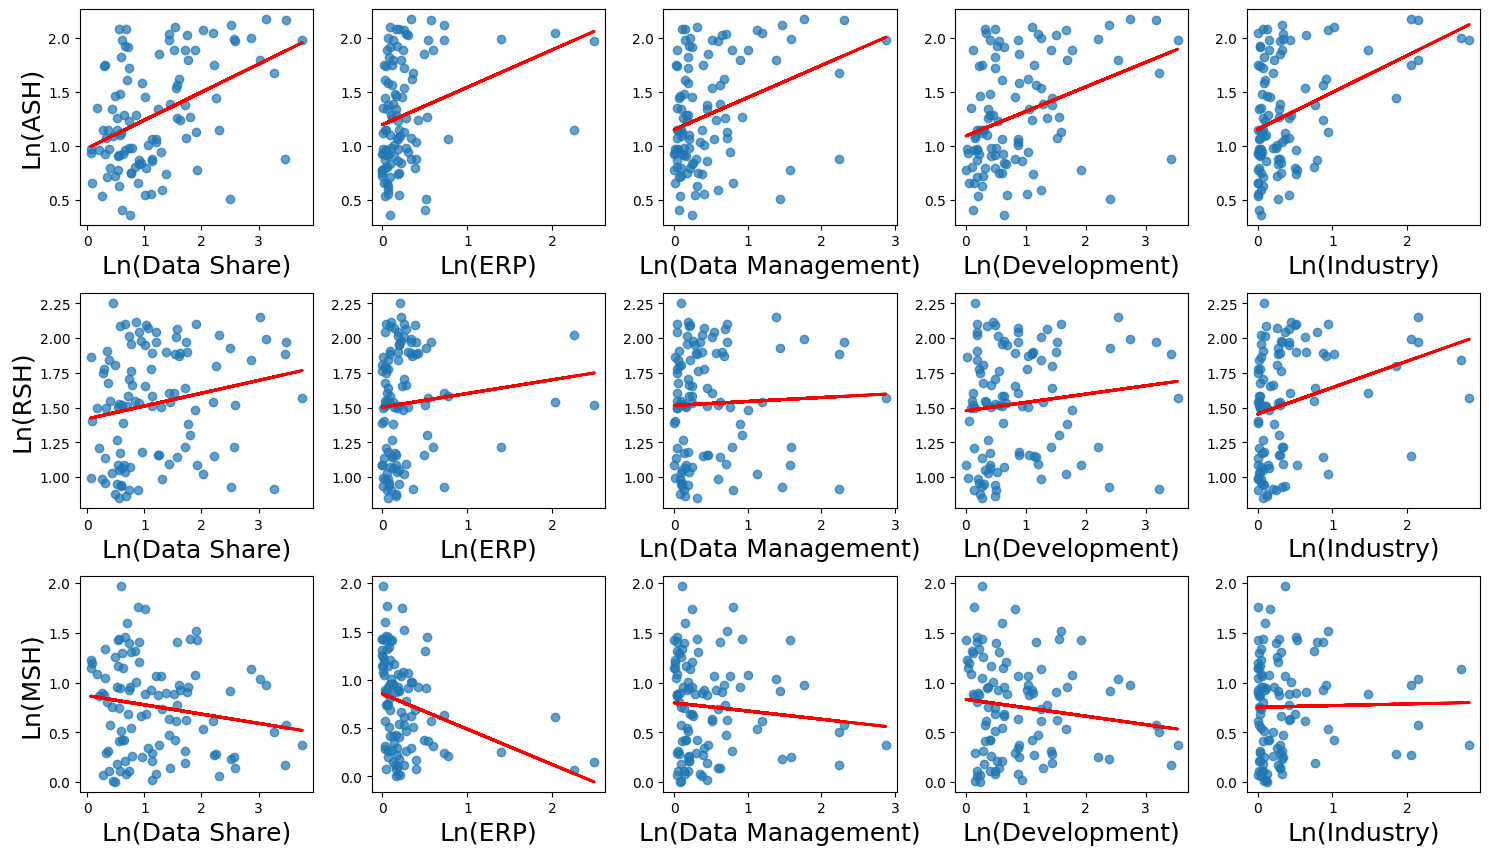

In [52]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming dfSoc_Fig_collapsed is your DataFrame

# Define the columns for independent and dependent variables
independent_vars = ['indust1_t', 'ERP_t', 'query_t', 'development_t', 'industry_t']
dependent_vars = ['task_abstract', 'task_routine', 'task_manual']

# Define the new labels for independent variables
independent_labels = ['Ln(Data Share)', 'Ln(ERP)', 'Ln(Data Management)', 'Ln(Development)', 'Ln(Industry)']

# Define new y-axis labels for each row
y_axis_labels = ['Ln(ASH)', 'Ln(RSH)', 'Ln(MSH)']

# Create a 3x4 grid for the scatter plots
fig, axes = plt.subplots(3, 5, figsize=(15, 10))

# Iterate through dependent variables (rows)
for i, (dep_var, y_label) in enumerate(zip(dependent_vars, y_axis_labels)):
    # Iterate through independent variables (columns)
    for j, (indep_var, indep_label) in enumerate(zip(independent_vars, independent_labels)):
        # Extract x and y columns
        x = dfSoc_Fig_collapsed[indep_var]
        y = dfSoc_Fig_collapsed[dep_var]

        # Combine x and y into a DataFrame and drop NaNs or infs from both columns
        data_clean = pd.DataFrame({indep_var: x, dep_var: y}).replace([np.inf, -np.inf], np.nan).dropna()

        # Scatter plot for each pair
        axes[i, j].scatter(data_clean[indep_var], data_clean[dep_var], alpha=0.7)
        
        # Fit and plot a linear regression line if there are enough valid points
        if len(data_clean) > 1:  # Ensure there's enough data for a fit
            try:
                # Get the coefficients of the linear fit
                coeffs = np.polyfit(data_clean[indep_var], data_clean[dep_var], 1)
                # Generate the fitted line
                y_fit = np.polyval(coeffs, data_clean[indep_var])
                # Plot the fitted line
                axes[i, j].plot(data_clean[indep_var], y_fit, color='red', linewidth=2)
            except np.linalg.LinAlgError:
                print(f"Linear regression failed for {indep_var} vs {dep_var}")
            
        # Set the x and y labels with increased font size
        axes[i, j].set_xlabel(indep_label, fontsize=18)
        if j == 0:  # Only label the y-axis on the first column
            axes[i, j].set_ylabel(y_label, fontsize=18)

# Adjust the layout to prevent overlapping elements
plt.tight_layout(rect=[0, 0.03, 1, 0.9])

# export to 'D:\Dropbox\Dropbox\Paper with Yao-yu\Spatial Data Programming\Draft\Data' as 'ash_corr.png'  
plt.savefig('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Draft/Data/ash_corr.png')

# Show the plot
plt.show()

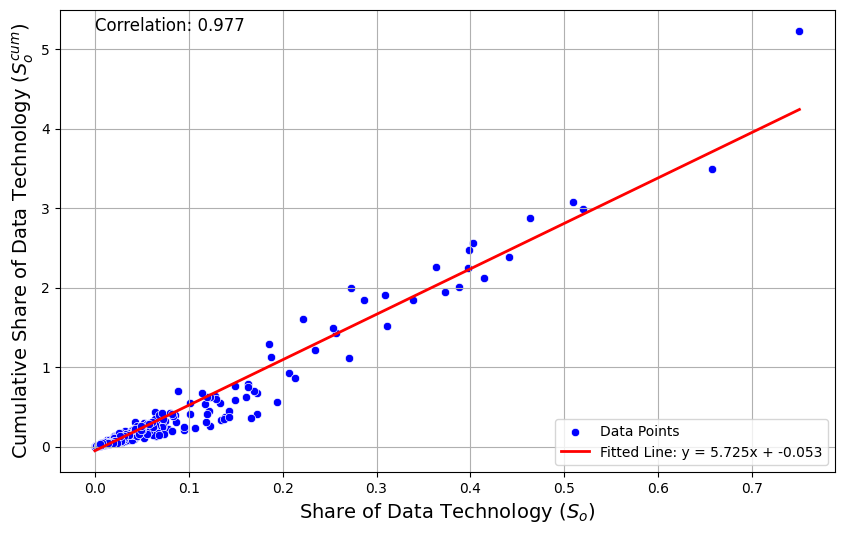

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dfSoc = pd.read_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/spatial_soc.csv')

# Drop NaN values from the columns to be plotted
dfSoc = dfSoc.dropna(subset=['dptSoc', 'dptSoc_sum'])

# Scatter plot
plt.figure(figsize=(10, 6))

# Add the scatter plot
sns.scatterplot(x='dptSoc', y='dptSoc_sum', data=dfSoc, color='blue', label='Data Points')

# Fit a line to the scatter plot data
coefficients = np.polyfit(dfSoc['dptSoc'], dfSoc['dptSoc_sum'], 1)
polynomial = np.poly1d(coefficients)
x_fit = np.linspace(min(dfSoc['dptSoc']), max(dfSoc['dptSoc']), 100)
y_fit = polynomial(x_fit)

# Add the fitted line
plt.plot(x_fit, y_fit, color='red', linewidth=2, label=f"Fitted Line: y = {coefficients[0]:.3f}x + {coefficients[1]:.3f}")

# Calculate and show the correlation coefficient
correlation = np.corrcoef(dfSoc['dptSoc'], dfSoc['dptSoc_sum'])[0, 1]
plt.text(min(dfSoc['dptSoc']), max(dfSoc['dptSoc_sum']), f"Correlation: {correlation:.3f}", fontsize=12)

# Labels and title
plt.xlabel('Share of Data Technology ($S_{o}$)', fontsize=14)
plt.ylabel('Cumulative Share of Data Technology ($S_{o}^{cum}$)', fontsize=14)
plt.title('', fontsize=16)
plt.legend(loc='lower right')
plt.grid(True)

# Show the plot
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_38052\3527088633.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table_adjusted = pd.pivot_table(dfSoc, values='soc_code', index='dptSoc_bin', columns='count_bin', aggfunc='count', fill_value=0)


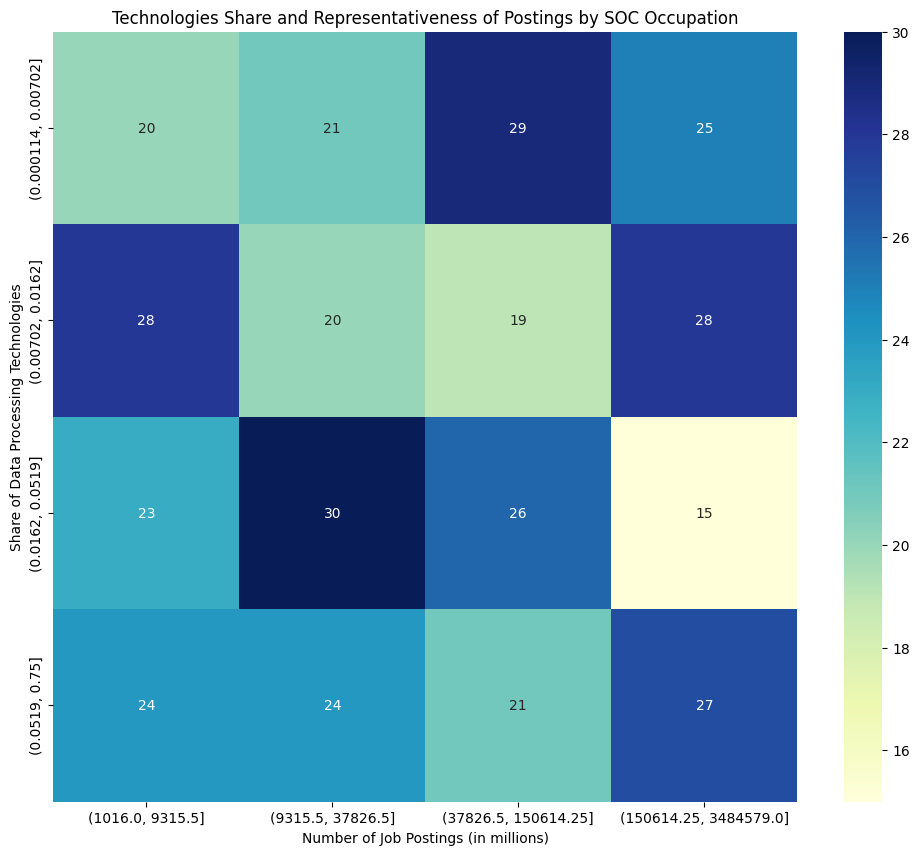

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Adjust the bins based on the actual distribution of 'dptSoc' and 'count'
# Using percentiles for more adaptive binning
dptSoc_bins = [dfSoc['dptSoc'].min(), dfSoc['dptSoc'].quantile(0.25), dfSoc['dptSoc'].quantile(0.5), 
               dfSoc['dptSoc'].quantile(0.75), dfSoc['dptSoc'].max()]
count_bins = [dfSoc['count'].min(), dfSoc['count'].quantile(0.25), dfSoc['count'].quantile(0.5), 
              dfSoc['count'].quantile(0.75), dfSoc['count'].max()]

# Bin 'dptSoc' and 'count' with adjusted bins
dfSoc['dptSoc_bin'] = pd.cut(dfSoc['dptSoc'], bins=dptSoc_bins)
dfSoc['count_bin'] = pd.cut(dfSoc['count'], bins=count_bins)

# Create a new pivot table for the heatmap with adjusted bins
pivot_table_adjusted = pd.pivot_table(dfSoc, values='soc_code', index='dptSoc_bin', columns='count_bin', aggfunc='count', fill_value=0)

# Create the heatmap with adjusted bins
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table_adjusted, annot=True, cmap="YlGnBu", fmt="d")
plt.title('Technologies Share and Representativeness of Postings by SOC Occupation')
plt.xlabel('Number of Job Postings (in millions)')
plt.ylabel('Share of Data Processing Technologies')
plt.show()

#### Generate `top and bottom 5 occupations` by the share of data processing, and count the number of postings in each occupation
- Table in `Latex` format

In [34]:
# Extract the first 2 digits of 'soc_code'
# Create a new DataFrame excluding rows where 'soc_code' is NaN
filtered_dataframe2_no_nan = filtered_dataframe2[filtered_dataframe2['soc_code'].notna()]
filtered_dataframe2_no_nan['soc_code_2digit'] = filtered_dataframe2_no_nan['soc_code'].apply(lambda x: int(str(int(x))[:2]))

# Collapse the data by the first 2 digits of 'soc_code'
collapsed_dfSoc = filtered_dataframe2_no_nan.groupby('soc_code_2digit').agg({
    'data_software': 'mean',
    'data_software_sum': 'mean',
    'posting_count': 'sum'
}).reset_index()

del filtered_dataframe2_no_nan
gc.collect()


# Load the soc_major dataset
df_soc_major = pd.read_excel('G:/Data/job_posting/processed/soc_major.xlsx')
# Extract the first 2 digits of 'Major Group'
df_soc_major['Major_Group_2digit'] = df_soc_major['Major Group'].apply(lambda x: int(str(x)[:2]))
# Merge the collapsed data with soc_major
merged_df = pd.merge(collapsed_dfSoc, df_soc_major, left_on='soc_code_2digit', right_on='Major_Group_2digit', how='inner')

C:\Users\DELL\AppData\Local\Temp\ipykernel_38052\1327921413.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_dataframe2_no_nan['soc_code_2digit'] = filtered_dataframe2_no_nan['soc_code'].apply(lambda x: int(str(int(x))[:2]))


In [35]:
import pandas as pd

# Assume df is your DataFrame
df = merged_df

# Sort and get top 5 and bottom 5 for each metric
top5_data_software = df.nlargest(5, 'data_software')
bottom5_data_software = df.nsmallest(5, 'data_software')

top5_data_software_sum = df.nlargest(5, 'data_software_sum')
bottom5_data_software_sum = df.nsmallest(5, 'data_software_sum')

top5_posting_count = df.nlargest(5, 'posting_count')
bottom5_posting_count = df.nsmallest(5, 'posting_count')

# Create LaTeX table with formatted numbers and trimmed occupation names
latex_table = r'''
\begin{table}[h]
\centering
\begin{tabular}{|c|c|c|c|c|c|}
\hline
Occupation (Top 5) & Data Software & Occupation (Top 5) & Data Software Sum & Occupation (Top 5) & Posting Count \\
\hline
'''

for i in range(5):
    occupation_name = top5_data_software.iloc[i]['Unnamed: 1'].replace(" Occupations", "")
    latex_table += f"{occupation_name} & {top5_data_software.iloc[i]['data_software']:.3f} & "
    
    occupation_name = top5_data_software_sum.iloc[i]['Unnamed: 1'].replace(" Occupations", "")
    latex_table += f"{occupation_name} & {top5_data_software_sum.iloc[i]['data_software_sum']:.3f} & "
    
    occupation_name = top5_posting_count.iloc[i]['Unnamed: 1'].replace(" Occupations", "")
    latex_table += f"{occupation_name} & {top5_posting_count.iloc[i]['posting_count']:.3f} \\\\ \n"

latex_table += r'\hline'
latex_table += 'Occupation (Bottom 5) & Data Software & Occupation (Bottom 5) & Data Software Sum & Occupation (Bottom 5) & Posting Count \\\\ \n'
latex_table += r'\hline'

for i in range(5):
    occupation_name = bottom5_data_software.iloc[i]['Unnamed: 1'].replace(" Occupations", "")
    latex_table += f"{occupation_name} & {bottom5_data_software.iloc[i]['data_software']:.3f} & "
    
    occupation_name = bottom5_data_software_sum.iloc[i]['Unnamed: 1'].replace(" Occupations", "")
    latex_table += f"{occupation_name} & {bottom5_data_software_sum.iloc[i]['data_software_sum']:.3f} & "
    
    occupation_name = bottom5_posting_count.iloc[i]['Unnamed: 1'].replace(" Occupations", "")
    latex_table += f"{occupation_name} & {bottom5_posting_count.iloc[i]['posting_count']:.3f} \\\\ \n"

latex_table += r'''
\hline
\end{tabular}
\caption{Top 5 and Bottom 5 Occupations by Different Metrics}
\end{table}
'''

print(latex_table)



\begin{table}[h]
\centering
\begin{tabular}{|c|c|c|c|c|c|}
\hline
Occupation (Top 5) & Data Software & Occupation (Top 5) & Data Software Sum & Occupation (Top 5) & Posting Count \\
\hline
Computer and Mathematical & 0.623 & Computer and Mathematical & 4.177 & Management & 15283450.000 \\ 
Architecture and Engineering & 0.238 & Architecture and Engineering & 1.105 & Sales and Related & 10981886.000 \\ 
Business and Financial Operations & 0.066 & Business and Financial Operations & 0.237 & Office and Administrative Support & 9276125.000 \\ 
Arts, Design, Entertainment, Sports, and Media & 0.058 & Educational Instruction and Library & 0.208 & Business and Financial Operations & 7171130.000 \\ 
Life, Physical, and Social Science & 0.046 & Management & 0.202 & Arts, Design, Entertainment, Sports, and Media & 4945207.000 \\ 
\hlineOccupation (Bottom 5) & Data Software & Occupation (Bottom 5) & Data Software Sum & Occupation (Bottom 5) & Posting Count \\ 
\hlineBuilding and Grounds Cleaning

### Visualize the `representativeness of postings and share of data processing` by industries
- generate the dataframe `dfInd0` and make a bar plot based on it to show the representativeness of postings by industries
- process the dataframe `dfInd1`
- generate the summary statistics: median, standard deviation, and gini coefficient
- KDE plot to visualize the distribution of the share of data processing by `parent, branch and local firms`

#### Make a Table to the `top and bottom 5 industries` by the share of data processing, and count the number of postings in each industry 

In [12]:
import pandas as pd

# Step 1: Collapse the data by aggregating on specified columns
collapsed_df = filtered_dataframe2.groupby(
    ['majorInd_name']
).agg({
    'data_software': 'mean',
    'posting_count': 'sum'
}).reset_index()

# Step 2: Filter data by keeping only rows where 'posting_count' > 100
collapsed_df = collapsed_df[collapsed_df['posting_count'] > 100]

# Step 3: Get top 5 and bottom 5 for each metric
top5_data_software = collapsed_df.nlargest(5, 'data_software')
bottom5_data_software = collapsed_df.nsmallest(5, 'data_software')

top5_posting_count = collapsed_df.nlargest(5, 'posting_count')
bottom5_posting_count = collapsed_df.nsmallest(5, 'posting_count')

# Step 4: Generate LaTeX table without the middle column
latex_table = r'''
\begin{table}[h]
\centering
\begin{tabular}{|c|c|c|c|}
\hline
Industries (Top 5) & Data Software & Industries (Top 5) & Posting Count \\
\hline
'''

# Top 5 rows
for i in range(5):
    # Get the industry names for each metric
    industry_data_software = top5_data_software.iloc[i]['majorInd_name']
    industry_posting_count = top5_posting_count.iloc[i]['majorInd_name']
    
    # Format the rows
    latex_table += f"{industry_data_software} & {top5_data_software.iloc[i]['data_software']:.3f} & "
    latex_table += f"{industry_posting_count} & {top5_posting_count.iloc[i]['posting_count']:.3f} \\\\ \n"

# Bottom 5 rows
latex_table += r'\hline'
latex_table += 'Industries (Bottom 5) & Data Software & Industries (Bottom 5) & Posting Count \\\\ \n'
latex_table += r'\hline'

for i in range(5):
    # Get the industry names for each metric
    industry_data_software = bottom5_data_software.iloc[i]['majorInd_name']
    industry_posting_count = bottom5_posting_count.iloc[i]['majorInd_name']
    
    # Format the rows
    latex_table += f"{industry_data_software} & {bottom5_data_software.iloc[i]['data_software']:.3f} & "
    latex_table += f"{industry_posting_count} & {bottom5_posting_count.iloc[i]['posting_count']:.3f} \\\\ \n"

# Finalize the LaTeX table
latex_table += r'''
\hline
\end{tabular}
\caption{Top 5 and Bottom 5 Industries by Data Software and Posting Count}
\end{table}
'''

print(latex_table)



\begin{table}[h]
\centering
\begin{tabular}{|c|c|c|c|}
\hline
Industries (Top 5) & Data Software & Industries (Top 5) & Posting Count \\
\hline
Software and Information Technology Services Industry & 0.186 & Business Services & 15060585.000 \\ 
Internet and Related Services & 0.164 & Wholesale Industry & 13442662.000 \\ 
Technology Promotion and Application Services & 0.160 & Software and Information Technology Services Industry & 9075374.000 \\ 
Other Financial Industries & 0.128 & Technology Promotion and Application Services & 7231885.000 \\ 
Telecommunications, Broadcasting Television and Satellite Transmission Services & 0.117 & Real Estate Industry & 3749691.000 \\ 
\hlineIndustries (Bottom 5) & Data Software & Industries (Bottom 5) & Posting Count \\ 
\hlineAccommodation Industry & 0.009 & Tobacco Products Industry & 479.000 \\ 
Catering Industry & 0.012 & Oil and Natural Gas Extraction & 507.000 \\ 
Insurance Industry & 0.014 & Pipeline Transport Industry & 670.000 \\ 
Sports 

In [14]:
### Generate the change in industrial employment share from the job postings  
dfInd0 = filtered_dataframe2.groupby(['year', '一级行业_categoryStrBig'])['data_software'].mean().reset_index()
dfInd0.rename(columns = {'data_software': 'dptInd'}, inplace=True)
# count number of observations by '城市_city', 'year'
dfInd0['count'] = filtered_dataframe2.groupby(['year', '一级行业_categoryStrBig'])['posting_count'].sum().reset_index()['posting_count']
# Sort by '一级行业_categoryStrBig' and 'year'
dfInd0.sort_values(by=['一级行业_categoryStrBig', 'year'], inplace=True)
# Calculate 'count_share' for each '一级行业_categoryStrBig' for each year
dfInd0['total_count_by_year'] = dfInd0.groupby('year')['count'].transform('sum')
dfInd0['count_share'] = dfInd0['count'] / dfInd0['total_count_by_year']
# Sort DataFrame to make sure it's in the correct order for the following calculations
dfInd0.sort_values(by=['一级行业_categoryStrBig', 'year'], inplace=True)
# remove obs if year == 2017
dfInd0 = dfInd0[dfInd0['year'] != 2018]
# Calculate the growth of 'count_share' for each '一级行业_categoryStrBig'
dfInd0['count_share_growth'] = dfInd0.groupby('一级行业_categoryStrBig')['count_share'].diff()
# remove obs if year == 2017
dfInd0 = dfInd0[dfInd0['year'] != 2017]
# rename column 'count_share_growth' to 'count_growth'
dfInd0.rename(columns={'count_share_growth': 'count_growth'}, inplace=True)
# keep columns '一级行业_categoryStrBig', 'count_growth' 
dfInd0 = dfInd0[['一级行业_categoryStrBig', 'count_growth']]
dfInd0

,一级行业_categoryStrBig,count_growth
0,交通运输、仓储和邮政业,NaN
57,交通运输、仓储和邮政业,-0.001218
1,住宿和餐饮业,NaN
58,住宿和餐饮业,-0.009464
2,信息传输、软件和信息技术服务业,NaN
59,信息传输、软件和信息技术服务业,-0.004950
3,公共管理、社会保障和社会组织,NaN
60,公共管理、社会保障和社会组织,-0.000031
4,农、林、牧、渔业,NaN
61,农、林、牧、渔业,-0.001170


In [15]:
### Extract the change in indutrial employment share from yearbook

# Sort by '一级行业_categoryStrBig' and 'year'
df_samplingShare2 = df_samplingShare.groupby(['year', '一级行业_categoryStrBig'])['samplingValue'].sum().reset_index()
df_samplingShare2.sort_values(by=['一级行业_categoryStrBig', 'year'], inplace=True)

# Calculate 'count_share' for each '一级行业_categoryStrBig' for each year
df_samplingShare2['total_count_by_year'] = df_samplingShare2.groupby('year')['samplingValue'].transform('sum')
df_samplingShare2['count_share'] = df_samplingShare2['samplingValue'] / df_samplingShare2['total_count_by_year']
# Sort DataFrame to make sure it's in the correct order for the following calculations
df_samplingShare2.sort_values(by=['一级行业_categoryStrBig', 'year'], inplace=True)
# remove obs if year == 2017
df_samplingShare2 = df_samplingShare2[df_samplingShare2['year'] != 2018]
# Calculate the growth of 'count_share' for each '一级行业_categoryStrBig'
df_samplingShare2['count_share_growth'] = df_samplingShare2.groupby('一级行业_categoryStrBig')['count_share'].diff()
# remove obs if year == 2017
df_samplingShare2 = df_samplingShare2[df_samplingShare2['year'] != 2017]

# keep columns '一级行业_categoryStrBig', 'count_share_growth'
df_samplingShare2 = df_samplingShare2[['一级行业_categoryStrBig', 'count_share_growth']]
# rename column 'count_share_growth' to 'yearbook_growth'
df_samplingShare2.rename(columns = {'count_share_growth': 'yearbook_growth'}, inplace=True)
df_samplingShare2

,一级行业_categoryStrBig,yearbook_growth
38,交通运输、仓储和邮政业,-0.003226
39,住宿和餐饮业,0.000895
40,信息传输、软件和信息技术服务业,0.003172
41,公共管理、社会保障和社会组织,0.015115
42,农、林、牧、渔业,-0.001534
43,制造业,-0.040105
44,卫生和社会工作,0.007176
45,居民服务、修理和其他服务业,0.000603
46,建筑业,-0.014538
47,房地产业,0.004537


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


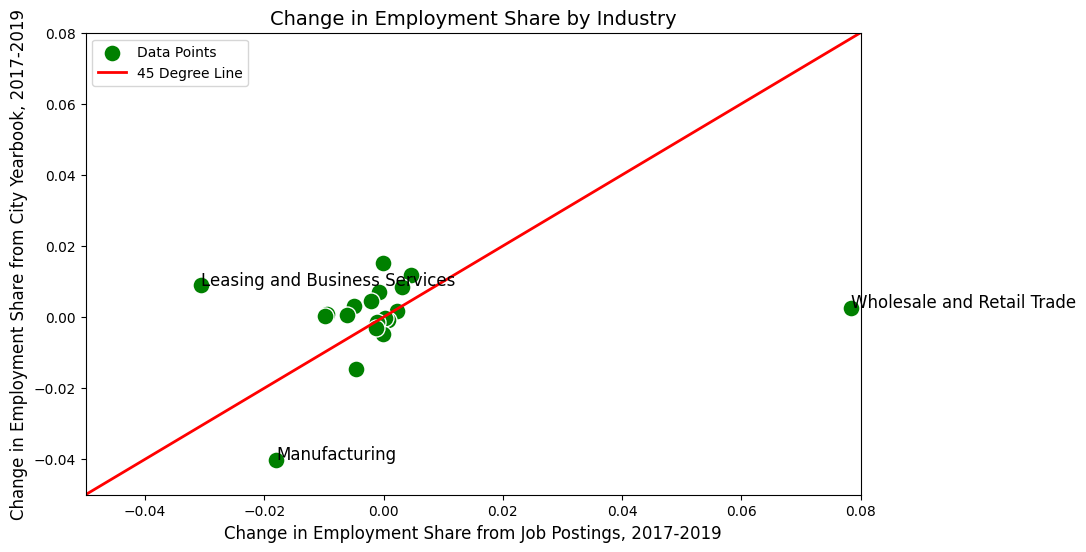

In [16]:
## merge 'dfInd0' with 'df_samplingShare2' on '一级行业_categoryStrBig' and generate the scatter plot
dfInd3 = pd.merge(dfInd0, df_samplingShare2, on='一级行业_categoryStrBig', how='left')
# keep columns '一级行业_categoryStrBig', 'count_share', 'yearbook_share'
dfInd3 = dfInd3[['一级行业_categoryStrBig', 'count_growth', 'yearbook_growth']]

## make the bar plot
# Create a dictionary for translating '一级行业_categoryStrBig' to English
translations = {
    '交通运输、仓储和邮政业': 'Transportation, Storage and Postal Services',
    '住宿和餐饮业': 'Accommodation and Catering Services',
    '信息传输、软件和信息技术服务业': 'Information Transmission, Software, and IT Services',
    '公共管理、社会保障和社会组织': 'Public Management, Social Security, and Social Organizations',
    '农、林、牧、渔业': 'Agriculture, Forestry, Animal Husbandry, and Fishery',
    '制造业': 'Manufacturing',
    '卫生和社会工作': 'Health and Social Work',
    '居民服务、修理和其他服务业': 'Residential Services, Repairs, and Other Services',
    '建筑业': 'Construction',
    '房地产业': 'Real Estate',
    '批发和零售业': 'Wholesale and Retail Trade',
    '教育': 'Education',
    '文化、体育和娱乐业': 'Culture, Sports, and Entertainment',
    '水利、环境和公共设施管理业': 'Water Conservancy, Environment, and Public Facilities Management',
    '电力、热力、燃气及水生产和供应业': 'Electricity, Heat, Gas, and Water Production and Supply',
    '科学研究和技术服务业': 'Scientific Research and Technical Services',
    '租赁和商务服务业': 'Leasing and Business Services',
    '采矿业': 'Mining',
    '金融业': 'Finance'
}

# Translate the '一级行业_categoryStrBig' to English
dfInd3['Industry_English'] = dfInd3['一级行业_categoryStrBig'].map(translations)

# Sort the DataFrame based on 'count_share' in descending order
df_sorted = dfInd3.sort_values(by='count_growth', ascending=False)

# Create the polished scatter plot
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(x='count_growth', y='yearbook_growth', data=df_sorted, color='green', s=150, label='Data Points')

# Add a 45-degree line
plt.plot([-0.05, 0.08], [-0.05, 0.08], color='red', linewidth=2, label='45 Degree Line')

# Annotate specific outlier points
outliers = ['Manufacturing', 'Leasing and Business Services', 'Wholesale and Retail Trade']
for i in range(df_sorted.shape[0]):
    if df_sorted.loc[i, 'Industry_English'] in outliers:
        plt.text(df_sorted.loc[i, 'count_growth'], df_sorted.loc[i, 'yearbook_growth'], df_sorted.loc[i, 'Industry_English'], fontsize=12)

# Adjust axis ranges
plt.xlim(-0.05, 0.08)
plt.ylim(-0.05, 0.08)

# Add title and labels
plt.title('Change in Employment Share by Industry', fontsize=14)
plt.xlabel('Change in Employment Share from Job Postings, 2017-2019', fontsize=12)
plt.ylabel('Change in Employment Share from City Yearbook, 2017-2019', fontsize=12)
plt.legend()

# Show the plot
plt.show()

In [19]:
## Industry level 1 dataframe `dfInd1`
 
# compute the 'indust1_t' column as share of 'software_data' at industry level 1-year level:
dfInd1 = filtered_dataframe2.groupby(['一级行业_categoryStrBig', '二级行业_categoryStrMiddle'])['data_software'].mean().reset_index()
dfInd1.rename(columns = {'data_software': 'dptInd'}, inplace=True)

dfInd1['dptIndBranch'] = dfBranch.groupby(['一级行业_categoryStrBig', '二级行业_categoryStrMiddle'])['data_software'].mean().reset_index()['data_software']
dfInd1['dptIndParent'] = dfParent.groupby(['一级行业_categoryStrBig', '二级行业_categoryStrMiddle'])['data_software'].mean().reset_index()['data_software']
dfInd1['dptIndLocal'] = dfLocal.groupby(['一级行业_categoryStrBig', '二级行业_categoryStrMiddle'])['data_software'].mean().reset_index()['data_software']
dfInd1['dptInd_sum'] = filtered_dataframe2.groupby(['一级行业_categoryStrBig', '二级行业_categoryStrMiddle'])['data_software_sum'].mean().reset_index()['data_software_sum']

# count number of observations by '城市_city', 'year'
dfInd1['count'] = filtered_dataframe2.groupby(['一级行业_categoryStrBig', '二级行业_categoryStrMiddle'])['posting_count'].sum().reset_index()['posting_count']
# replace 'soc_t', 'socBranch_t', 'socParent_t', 'socLocal_t' with null if 'count' < 5000
dfInd1.loc[dfInd1['count'] < 1000, ['dptInd', 'dptInd_sum', 'dptIndBranch', 'dptIndParent', 'dptIndLocal']] = np.nan
# normalize 'dptSoc' by '1000000' 
dfInd1['count'] = dfInd1['count'] / 1000000

# load xlsx file 'Industry_2017' from 'G:\Data' folder. The raw classification follows `GB/T 4754-2011`
dfInd2 = pd.read_excel('G:/Data/unclassified/Industry_2017.xlsx', sheet_name='Sheet1')
# merge with 'dfInd1_t' on '二级行业_categoryStrMiddle', keep all observations in 'dfInd1_t'
dfInd1 = pd.merge(dfInd1, dfInd2, how='left', on='二级行业_categoryStrMiddle')
dfInd1.head(10)

,一级行业_categoryStrBig,二级行业_categoryStrMiddle,dptInd,dptIndBranch,dptIndParent,dptIndLocal,dptInd_sum,count,majorInd_code,majorInd_name
0,交通运输、仓储和邮政业,多式联运和运输代理业,0.025964,0.028418,0.033457,0.021513,0.123984,0.404633,58.0,Loading and Unloading Handling and Transport A...
1,交通运输、仓储和邮政业,水上运输业,0.036320,0.050543,0.043778,0.024716,0.150580,0.026046,55.0,Water Transport Industry
2,交通运输、仓储和邮政业,管道运输业,NaN,NaN,NaN,NaN,NaN,0.000670,57.0,Pipeline Transport Industry
3,交通运输、仓储和邮政业,航空运输业,0.055472,0.044690,0.066237,0.042331,0.321482,0.025202,56.0,Air Transport Industry
4,交通运输、仓储和邮政业,装卸搬运和仓储业,0.045263,0.032802,0.055787,0.035140,0.178782,0.105805,59.0,Warehousing Industry
5,交通运输、仓储和邮政业,道路运输业,0.025516,0.016836,0.039368,0.018442,0.118428,0.635525,54.0,Road Transport Industry
6,交通运输、仓储和邮政业,邮政业,0.025835,0.014892,0.041249,0.012556,0.121647,0.118211,60.0,Postal Industry
7,交通运输、仓储和邮政业,铁路运输业,0.059024,0.006689,0.100147,0.027616,0.325088,0.007641,53.0,Railway Transport Industry
8,住宿和餐饮业,住宿业,0.009244,0.012280,0.015315,0.007253,0.035716,0.285252,61.0,Accommodation Industry
9,住宿和餐饮业,餐饮业,0.012476,0.006551,0.020105,0.009223,0.040915,0.709031,62.0,Catering Industry


In [20]:
def gini_coefficient(x):
    """Compute Gini coefficient of array of values"""
    x = np.array(x.dropna())  # Drop NaN values
    n = len(x)
    s = x.sum()
    r = np.argsort(np.argsort(-x))  # Calculates zero-based ranks
    return 1 - (2 * (r * x).sum() + s) / (n * s)

# Calculate Gini coefficients for each column
gini_coeffs = {
    'dptSoc': gini_coefficient(dfSoc['dptSoc']),
    'dptInd': gini_coefficient(dfInd1['dptInd']),
    'dptIndBranch': gini_coefficient(dfInd1['dptIndBranch']),
    'dptIndParent': gini_coefficient(dfInd1['dptIndParent']),
    'dptIndLocal': gini_coefficient(dfInd1['dptIndLocal'])
}

# Calculate and mark medians
means = {
    'dptSoc': dfSoc['dptSoc'].median(),
    'dptInd': dfInd1['dptInd'].median(),
    'dptIndBranch': dfInd1['dptIndBranch'].median(),
    'dptIndParent': dfInd1['dptIndParent'].median(),
    'dptIndLocal': dfInd1['dptIndLocal'].median()
}

# Calculate and store standard deviations
std_devs = {
    'dptSoc': dfSoc['dptSoc'].std(),
    'dptInd': dfInd1['dptInd'].std(),
    'dptIndBranch': dfInd1['dptIndBranch'].std(),
    'dptIndParent': dfInd1['dptIndParent'].std(),
    'dptIndLocal': dfInd1['dptIndLocal'].std()
}

print(gini_coeffs)
print(means)
print(std_devs)

{'dptSoc': 0.6885748819452094, 'dptInd': 0.3221923021277775, 'dptIndBranch': 0.48234051276037126, 'dptIndParent': 0.34279776674812523, 'dptIndLocal': 0.34270830129267704}
{'dptSoc': 0.01617763590086865, 'dptInd': 0.039465544970926636, 'dptIndBranch': 0.03288464113206381, 'dptIndParent': 0.048683239967305274, 'dptIndLocal': 0.03662963021667116}
{'dptSoc': 0.09835198065311367, 'dptInd': 0.03301315212764516, 'dptIndBranch': 0.046217436796626446, 'dptIndParent': 0.04423890284739327, 'dptIndLocal': 0.03244670507781914}


c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: us

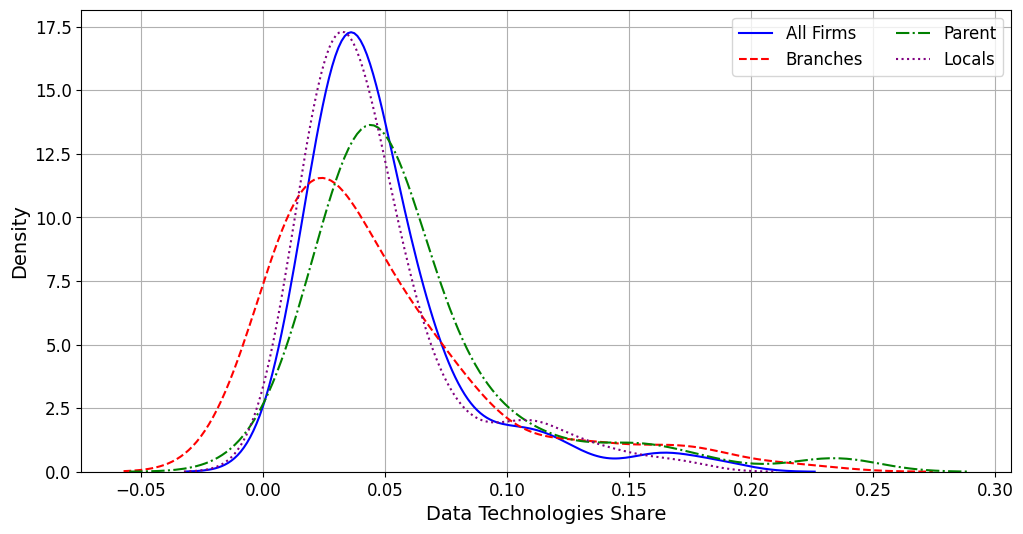

In [27]:
## Make the KDE plot
# Step 1: Import Required Libraries
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 2: Initialize Figure
plt.figure(figsize=(12, 6))

# Step 3: Draw the KDE Plots
sns.kdeplot(dfInd1['dptInd'], color='blue', linestyle='-', label='All Firms')
sns.kdeplot(dfInd1['dptIndBranch'], color='red', linestyle='--', label='Branches')
sns.kdeplot(dfInd1['dptIndParent'], color='green', linestyle='-.', label='Parent')
sns.kdeplot(dfInd1['dptIndLocal'], color='purple', linestyle=':', label='Locals')

# Step 4: Add Titles and Labels
plt.title('', fontsize=14)
plt.xlabel('Data Technologies Share', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(fontsize='12', ncol = 2)

# Step 5: Add Grid and Customize Ticks
plt.grid(True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Step 6: Show the Plot
plt.show()

#### The composition of the data processing share by industries (using full sample, not only parent firm)

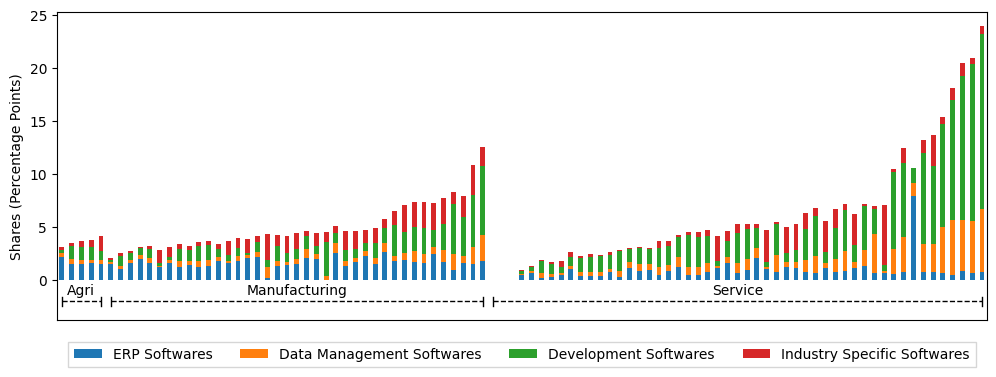

In [243]:
import pandas as pd
import matplotlib.pyplot as plt

# compute the 'indust1_t' column as share of 'software_data' at industry level 1-year level:
dfInd1_Fig = filtered_dataframe2.groupby(['majorInd_code'])['data_software'].mean().reset_index()
dfInd1_Fig.rename(columns = {'data_software': 'indust1_t'}, inplace=True)

dfInd1_Fig['ERP_t'] = filtered_dataframe2.groupby(['majorInd_code'])['Finance accounting and enterprise resource planning ERP software'].mean().reset_index()['Finance accounting and enterprise resource planning ERP software']
dfInd1_Fig['query_t'] = filtered_dataframe2.groupby(['majorInd_code'])['Data management and query software'].mean().reset_index()['Data management and query software']
dfInd1_Fig['development_t'] = filtered_dataframe2.groupby(['majorInd_code'])['Development software'].mean().reset_index()['Development software']
dfInd1_Fig['industry_t'] = filtered_dataframe2.groupby(['majorInd_code'])['Industry specific software'].mean().reset_index()['Industry specific software']

# load xlsx file 'Industry_2017' from 'G:\Data' folder. The raw classification follows `GB/T 4754-2011`
dfInd2 = pd.read_excel('G:/Data/unclassified/Industry_2017.xlsx', sheet_name='Sheet1')
# merge with 'dfInd1_t' on '二级行业_categoryStrMiddle', keep all observations in 'dfInd1_t'
dfInd1_Fig = pd.merge(dfInd1_Fig, dfInd2, how='left', on='majorInd_code')

# Read the dfBranchSector3 from the CSV (assuming this is done)
dfInd1_Fig.sort_values(by=['majorInd_code'], inplace=True)

# Multiply values by 100
dfInd1_Fig[['indust1_t', 'ERP_t', 'query_t', 'development_t', 'industry_t']] *= 100

# Fill missing values
df_filled = dfInd1_Fig.fillna(0)

# Create a new column 'sector' based on the categorization of 'majorInd_code' into agri, manufacturing, and service
def assign_sector(code):
    if 0 <= code <= 5:  # 0-5 for Agri
        return 'Agri'
    elif 6 <= code <= 44:  # 6-44 for Manufacturing
        return 'Manufacturing'
    else:  # Everything else for Service
        return 'Service'


df_filled['sector'] = df_filled['majorInd_code'].apply(assign_sector)

# Calculate averages and reset the index
averages = df_filled.groupby(['sector', 'majorInd_code'])[['indust1_t', 'ERP_t', 'query_t', 'development_t', 'industry_t']].mean().reset_index()

# Rename columns for better presentation
averages.rename(columns={'ERP_t': 'ERP Softwares', 'query_t': 'Data Management Softwares', 
                         'development_t': 'Development Softwares', 'industry_t': 'Industry Specific Softwares'}, inplace=True)

# Sort within each sector by 'indust1_t', ensuring the order of sectors is preserved as 'Agri', 'Manufacturing', 'Service'
sector_order = ['Agri', 'Manufacturing', 'Service']
averages['sector'] = pd.Categorical(averages['sector'], categories=sector_order, ordered=True)

# Now, we need to sort within each sector by 'indust1_t'
averages = averages.sort_values(by=['sector', 'indust1_t'], ascending=[True, True])

# Separate data for each sector to maintain the order and correct within-sector ranking
agri_data = averages[averages['sector'] == 'Agri']
manufacturing_data = averages[averages['sector'] == 'Manufacturing']
service_data = averages[averages['sector'] == 'Service']

# Concatenate the data back in the correct order (Agri, Manufacturing, Service)
sorted_averages = pd.concat([agri_data, manufacturing_data, service_data])

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
sorted_averages.set_index('majorInd_code')[['ERP Softwares', 'Data Management Softwares', 'Development Softwares', 'Industry Specific Softwares']].plot(kind='bar', stacked=True, ax=ax)

# Remove the x-axis completely
ax.xaxis.set_visible(False)

# Custom function to draw curly brackets with text inside the figure
def draw_line_with_text(ax, xspan, y, height, text, vertical_lines):
    """Draws an annotated straight line on the axes with text inside the figure."""
    xmin, xmax = xspan
    # Draw base line
    ax.plot([xmin, xmax], [y, y], color='black', linestyle='dashed', linewidth=1)  

    # Draw small vertical lines
    for x in vertical_lines:
        if xmin <= x <= xmax:  # Only draw if x is within the span
            ax.plot([x, x], [y - height * 0.2, y + height * 0.2], color='black', linewidth=1)

    # Adding text above the line
    ax.text((xmin + xmax) / 2, y + height * 0.2, text, ha='center', va='bottom', fontsize=10)

# Count the number of rows for each sector
agri_count = len(agri_data)
manufacturing_count = len(manufacturing_data)
service_count = len(service_data)

# Fixed height for brackets
brace_height = 2

# Define the positions of the sectors based on the number of entries
agri_range = (0, agri_count - 1)
manufacturing_range = (agri_count, agri_count + manufacturing_count - 1)
service_range = (agri_count + manufacturing_count, agri_count + manufacturing_count + service_count - 1)

# Draw curly brackets for each sector
draw_line_with_text(ax, agri_range, -brace_height, brace_height, 'Agri', list(agri_range))
draw_line_with_text(ax, manufacturing_range, -brace_height, brace_height, 'Manufacturing', list(manufacturing_range))
draw_line_with_text(ax, service_range, -brace_height, brace_height, 'Service', list(service_range))

# Move the legend outside the figure, in 1 row
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), fancybox=False, shadow=False, ncol=len(sorted_averages.columns)-1)

plt.title('')
plt.ylabel('Shares (Percentage Points)')
plt.xlabel('Ranked by Shares Within Sectors')

plt.show()

In [50]:
## Industry level 1 dataframe `dfInd1_t`
 
# compute the 'indust1_t' column as share of 'software_data' at industry level 1-year level:
dfInd1_t = filtered_dataframe2.groupby(['year', '一级行业_categoryStrBig', '二级行业_categoryStrMiddle'])['data_software'].mean().reset_index()
dfInd1_t.rename(columns = {'data_software': 'indust1_t'}, inplace=True)

dfInd1_t['ERP_t'] = filtered_dataframe2.groupby(['year', '一级行业_categoryStrBig', '二级行业_categoryStrMiddle'])['Finance accounting and enterprise resource planning ERP software'].mean().reset_index()['Finance accounting and enterprise resource planning ERP software']
dfInd1_t['query_t'] = filtered_dataframe2.groupby(['year', '一级行业_categoryStrBig', '二级行业_categoryStrMiddle'])['Data management and query software'].mean().reset_index()['Data management and query software']
dfInd1_t['development_t'] = filtered_dataframe2.groupby(['year', '一级行业_categoryStrBig', '二级行业_categoryStrMiddle'])['Development software'].mean().reset_index()['Development software']
dfInd1_t['industry_t'] = filtered_dataframe2.groupby(['year', '一级行业_categoryStrBig', '二级行业_categoryStrMiddle'])['Industry specific software'].mean().reset_index()['Industry specific software']
dfInd1_t['foreign_t'] = filtered_dataframe2.groupby(['year', '一级行业_categoryStrBig', '二级行业_categoryStrMiddle'])['ds_cn0'].mean().reset_index()['ds_cn0']

dfInd1_t['indust1Branch_t'] = dfBranch.groupby(['year', '一级行业_categoryStrBig', '二级行业_categoryStrMiddle'])['data_software'].mean().reset_index()['data_software']
dfInd1_t['indust1Parent_t'] = dfParent.groupby(['year', '一级行业_categoryStrBig', '二级行业_categoryStrMiddle'])['data_software'].mean().reset_index()['data_software']
dfInd1_t['indust1Local_t'] = dfLocal.groupby(['year', '一级行业_categoryStrBig', '二级行业_categoryStrMiddle'])['data_software'].mean().reset_index()['data_software']
dfInd1_t['indust1_t_sum'] = filtered_dataframe2.groupby(['year', '一级行业_categoryStrBig', '二级行业_categoryStrMiddle'])['data_software_sum'].mean().reset_index()['data_software_sum']

# count number of observations by '城市_city', 'year'
dfInd1_t['count'] = filtered_dataframe2.groupby(['year', '一级行业_categoryStrBig', '二级行业_categoryStrMiddle'])['posting_count'].sum().reset_index()['posting_count']
# replace 'soc_t', 'socBranch_t', 'socParent_t', 'socLocal_t' with null if 'count' < 5000
dfInd1_t.loc[dfInd1_t['count'] < 1000, ['ERP_t', 'query _t', 'development_t', 'industry_t', 'foreign_t', 'indust1_t', 'indust1_t_sum', 'indust1Branch_t', 'indust1Parent_t', 'indust1Local_t']] = np.nan
# normalize 'dptSoc' by '1000000' 
dfInd1_t['count'] = dfInd1_t['count'] / 1000000

# load xlsx file 'Industry_2017' from 'G:\Data' folder. The raw classification follows `GB/T 4754-2011`
dfInd2 = pd.read_excel('G:/Data/unclassified/Industry_2017.xlsx', sheet_name='Sheet1')
# merge with 'dfInd1_t' on '二级行业_categoryStrMiddle', keep all observations in 'dfInd1_t'
dfInd1_t = pd.merge(dfInd1_t, dfInd2, how='left', on='二级行业_categoryStrMiddle')
dfInd1_t.head(10)

,year,一级行业_categoryStrBig,二级行业_categoryStrMiddle,indust1_t,ERP_t,query_t,development_t,industry_t,foreign_t,indust1Branch_t,indust1Parent_t,indust1_t_sum,count,query _t,majorInd_code,majorInd_name
0,2016.0,交通运输、仓储和邮政业,多式联运和运输代理业,0.021572,0.009495,0.003204,0.010776,0.000621,0.014582,0.020704,0.025511,0.094289,0.051501,NaN,58,Loading and Unloading Handling and Transport A...
1,2016.0,交通运输、仓储和邮政业,水上运输业,0.020401,0.007158,0.003579,0.012169,0.000358,0.013958,0.035088,0.023709,0.093057,0.002794,NaN,55,Water Transport Industry
2,2016.0,交通运输、仓储和邮政业,管道运输业,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000113,NaN,57,Pipeline Transport Industry
3,2016.0,交通运输、仓储和邮政业,航空运输业,0.031720,0.004174,0.006260,0.023372,0.002087,0.028798,0.024055,0.036897,0.150250,0.002396,NaN,56,Air Transport Industry
4,2016.0,交通运输、仓储和邮政业,装卸搬运和仓储业,0.032551,0.017880,0.004432,0.012990,0.001223,0.022694,0.040084,0.038578,0.128219,0.013087,NaN,59,Warehousing Industry
5,2016.0,交通运输、仓储和邮政业,道路运输业,0.024677,0.014202,0.004110,0.008812,0.000784,0.014906,0.015513,0.029698,0.099765,0.062527,NaN,54,Road Transport Industry
6,2016.0,交通运输、仓储和邮政业,邮政业,0.015651,0.011161,0.002245,0.003207,0.000064,0.006543,0.015845,0.018370,0.050802,0.015590,NaN,60,Postal Industry
7,2016.0,交通运输、仓储和邮政业,铁路运输业,NaN,NaN,0.001060,NaN,NaN,NaN,NaN,NaN,NaN,0.000943,NaN,53,Railway Transport Industry
8,2016.0,住宿和餐饮业,住宿业,0.007445,0.005530,0.000340,0.001467,0.000394,0.002541,0.008532,0.007562,0.025018,0.055879,NaN,61,Accommodation Industry
9,2016.0,住宿和餐饮业,餐饮业,0.010970,0.007002,0.000334,0.003342,0.000514,0.005176,0.006438,0.016607,0.035343,0.116685,NaN,62,Catering Industry


### Generate data processing variables for each `city`.
- We create a new dataframe `dfProgram_pct` at the `year-province-city`.
- We create a new dataframe `dfProgram_pc` at the `province-city`. Then, make a scatter plot of the adjusted and unadjusted share of data processing by city.

In [7]:
## Generate the `dfProgram_pc` DataFrame

def process_dataframe(df, cols_to_process):
    
    # Calculate the sum of 'posting_count' for each group
    df['total_posting_count'] = df.groupby(['省份_province', '城市_city', '一级行业_categoryStrBig'])['posting_count'].transform('sum')
    
    # Filter out rows where 'total_posting_count' < 100
    df_filtered = df[df['total_posting_count'] >= 100]

    # Step 1: Calculate the group-wise mean of 'data_software'
    mean_software = df_filtered.groupby(['省份_province', '城市_city', '一级行业_categoryStrBig'])['data_software'].mean().reset_index()
    # Step 2: Identify the top 1% cutoff for 'data_software'
    cutoff = mean_software['data_software'].quantile(0.99)

    # Perform the grouping only once on the filtered data
    grouped_df = df_filtered.groupby(['省份_province', '城市_city', '一级行业_categoryStrBig'])
    
    # Pre-allocate an empty DataFrame to store the results
    summed_df = pd.DataFrame()
    
    # Calculate the total number of job postings at the 'year', '省份_province', '城市_city' level
    total_posting_by_city_year = df_filtered.groupby(['省份_province', '城市_city'])['posting_count'].sum().reset_index()
    
    # Step 4: Continue with Original Calculations
    for col in cols_to_process:
        mean_df = grouped_df[[col, 'samplingShare', 'samplingValue']].mean()
        mean_df = mean_df[mean_df[col] < cutoff]

        # Calculate weighted averages with different weights
        mean_df['shareW_pc'] = mean_df[col] * mean_df['samplingShare']
        mean_df['valueW_pc'] = mean_df[col] * mean_df['samplingValue']
        
        # Sum up the weighted shares
        sum_cols = ['shareW_pc', 'valueW_pc']
        summed_col = mean_df.groupby(['省份_province', '城市_city'])[sum_cols].sum().reset_index()
        
        # Calculate simple average
        simple_avg = df_filtered.groupby(['省份_province', '城市_city'])[col].mean().reset_index()
        simple_avg.rename(columns={col: f'{col}_avg'}, inplace=True)
        
        # Merge simple average and total postings into summed_col
        summed_col = pd.merge(summed_col, simple_avg, on=['省份_province', '城市_city'], how='outer')
        summed_col = pd.merge(summed_col, total_posting_by_city_year, on=['省份_province', '城市_city'], how='outer')

        # Rename the summed columns
        new_col_names = {old: f"{col}_{old}" for old in sum_cols}
        summed_col.rename(columns=new_col_names, inplace=True)
        
        # Merge the summed column into the result DataFrame
        if summed_df.empty:
            summed_df = summed_col
        else:
            summed_df = pd.merge(summed_df, summed_col, on=[ '省份_province', '城市_city'], how='outer')
    
    return summed_df

# Initialize
base_df_name = 'filtered_dataframe2'  # Replace with your actual DataFrame
dataframes = {'dfBranch': None, 'dfParent': None, 'dfLocal': None}  # Replace with your actual DataFrames
columns_to_process = ['data_software']

# Process the base DataFrame first
base_df = locals()[base_df_name]
dfProgram_pc = process_dataframe(base_df, columns_to_process)

# Process and merge the remaining DataFrames
for df_name in dataframes.keys():
    current_df = locals()[df_name]
    processed_df = process_dataframe(current_df, columns_to_process)
    
    # Rename the columns to include the DataFrame name
    processed_df.columns = [f"{df_name.replace('df', '')}_{col}" if col not in ['省份_province', '城市_city'] else col for col in processed_df.columns]
    
    # Merge the processed DataFrame into dfProgram_pc
    dfProgram_pc = pd.merge(dfProgram_pc, processed_df, on=['省份_province', '城市_city'], how='outer')

dfProgram_pc.head(10)

# Export the dataframe `dfProgram_pc`

# generate column 'progTop5' and 'progTop10' in 'dfProgram_pct' to indicate whether the city is in top 5% or 10% of programming share in the year
dfProgram_pc['progTop5'] = dfProgram_pc['data_software_valueW_pc'].transform(lambda x: x >= x.quantile(0.95))
dfProgram_pc['progTop10'] = dfProgram_pc['data_software_valueW_pc'].transform(lambda x: x >= x.quantile(0.90))

# export 'dfProgram_pct' to csv file at 'Desktop' 
#dfProgram_pc.to_csv('D:/Dropbox/Dropbox/DPT_crime/Data/spatial_tech_pc.csv', encoding='utf_8_sig', index=False)

KeyError: 'dfBranch'

In [ ]:
## Generate the `dfProgram_pct` DataFrame

def process_dataframe(df, cols_to_process):
    
    # Calculate the sum of 'posting_count' for each group
    df['total_posting_count'] = df.groupby(['year', '省份_province', '城市_city', '一级行业_categoryStrBig'])['posting_count'].transform('sum')
    
    # Filter out rows where 'total_posting_count' < 100
    df_filtered = df[df['total_posting_count'] >= 100]
    
    # Step 1: Calculate the group-wise mean of 'data_software'
    mean_software = df_filtered.groupby(['省份_province', '城市_city', '一级行业_categoryStrBig'])['data_software'].mean().reset_index()
    # Step 2: Identify the top 1% cutoff for 'data_software'
    cutoff = mean_software['data_software'].quantile(0.99)

    # Perform the grouping only once on the filtered data
    grouped_df = df_filtered.groupby(['year', '省份_province', '城市_city', '一级行业_categoryStrBig'])

    # Pre-allocate an empty DataFrame to store the results
    summed_df = pd.DataFrame()
    
    # Calculate the total number of job postings at the 'year', '省份_province', '城市_city' level
    total_posting_by_city_year = df_filtered.groupby(['year', '省份_province', '城市_city'])['posting_count'].sum().reset_index()
    
    # Iterate over each column to process
    for col in cols_to_process:
        mean_df = grouped_df[[col, 'samplingShare', 'samplingValue']].mean()
        mean_df = mean_df[mean_df[col] < cutoff]
            
        # Calculate weighted averages with different weights
        mean_df['shareW_pct'] = mean_df[col] * mean_df['samplingShare']
        mean_df['valueW_pct'] = mean_df[col] * mean_df['samplingValue']
        
        # Sum up the weighted shares
        sum_cols = ['shareW_pct', 'valueW_pct']
        summed_col = mean_df.groupby(['year', '省份_province', '城市_city'])[sum_cols].sum().reset_index()
        
        # Calculate simple average
        simple_avg = df_filtered.groupby(['year', '省份_province', '城市_city'])[col].mean().reset_index()
        simple_avg.rename(columns={col: f'{col}_avg'}, inplace=True)
        
        # Merge simple average and total postings into summed_col
        summed_col = pd.merge(summed_col, simple_avg, on=['year', '省份_province', '城市_city'], how='outer')
        summed_col = pd.merge(summed_col, total_posting_by_city_year, on=['year', '省份_province', '城市_city'], how='outer')

        # Rename the summed columns
        new_col_names = {old: f"{col}_{old}" for old in sum_cols}
        summed_col.rename(columns=new_col_names, inplace=True)
        
        # Merge the summed column into the result DataFrame
        if summed_df.empty:
            summed_df = summed_col
        else:
            summed_df = pd.merge(summed_df, summed_col, on=['year', '省份_province', '城市_city'], how='outer')
    
    return summed_df

# Initialize
base_df_name = 'filtered_dataframe2'  # Replace with your actual DataFrame
dataframes = {'dfBranch': None, 'dfParent': None, 'dfLocal': None}  # Replace with your actual DataFrames
columns_to_process = ['data_software']

# Process the base DataFrame first
base_df = locals()[base_df_name]
dfProgram_pct = process_dataframe(base_df, columns_to_process)

# Process and merge the remaining DataFrames
for df_name in dataframes.keys():
    current_df = locals()[df_name]
    processed_df = process_dataframe(current_df, columns_to_process)
    
    # Rename the columns to include the DataFrame name
    processed_df.columns = [f"{df_name.replace('df', '')}_{col}" if col not in ['year', '省份_province', '城市_city'] else col for col in processed_df.columns]
    
    # Merge the processed DataFrame into dfProgram_pct
    dfProgram_pct = pd.merge(dfProgram_pct, processed_df, on=['year', '省份_province', '城市_city'], how='outer')

dfProgram_pct.head(10)

dfProgram_pct.to_csv('D:/Dropbox/Dropbox/DPT_crime/Data/spatial_tech.csv', encoding='utf_8_sig', index=False)

C:\Users\DELL\AppData\Local\Temp\ipykernel_21084\2010960964.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['total_posting_count'] = df.groupby(['year', '省份_province', '城市_city', '一级行业_categoryStrBig'])['posting_count'].transform('sum')
C:\Users\DELL\AppData\Local\Temp\ipykernel_21084\2010960964.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['total_posting_count'] = df.groupby(['year', '省份_province', '城市_city', '一级行业_categoryStrBig'])['posting_count'].transform('sum')
C:\Users\DELL\AppData\Lo

,year,省份_province,城市_city,data_software_shareW_pct,data_software_valueW_pct,data_software_avg,posting_count,Branch_data_software_shareW_pct,Branch_data_software_valueW_pct,Branch_data_software_avg,Branch_posting_count,Parent_data_software_shareW_pct,Parent_data_software_valueW_pct,Parent_data_software_avg,Parent_posting_count,Local_data_software_shareW_pct,Local_data_software_valueW_pct,Local_data_software_avg,Local_posting_count
0,2016.0,上海,上海市,0.0,0.0,0.083423,814436.0,0.0,0.0,0.052497,29392.0,0.0,0.0,0.090569,271494.0,0.0,0.0,0.081428,513438.0
1,2016.0,云南,昆明市,0.0,0.0,0.046177,39132.0,0.0,0.0,0.015446,2525.0,0.0,0.0,0.041939,12232.0,0.0,0.0,0.051925,23996.0
2,2016.0,云南,曲靖市,0.0,0.0,0.000000,103.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016.0,云南,玉溪市,0.0,0.0,0.049505,101.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016.0,内蒙古,乌兰察布市,0.0,0.0,0.018692,107.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2016.0,内蒙古,包头市,0.0,0.0,0.024442,11742.0,0.0,0.0,0.007930,1261.0,0.0,0.0,0.016566,2656.0,0.0,0.0,0.030750,7187.0
6,2016.0,内蒙古,呼和浩特市,0.0,0.0,0.023957,12564.0,0.0,0.0,0.009311,1611.0,0.0,0.0,0.013810,2100.0,0.0,0.0,0.028102,8149.0
7,2016.0,内蒙古,巴彦淖尔市,0.0,0.0,0.031348,319.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.028708,209.0
8,2016.0,内蒙古,赤峰市,0.0,0.0,0.042953,745.0,NaN,NaN,NaN,NaN,0.0,0.0,0.090000,100.0,0.0,0.0,0.034314,408.0
9,2016.0,内蒙古,通辽市,0.0,0.0,0.036585,246.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.033113,151.0


#### `visualize the share of data processing and other city characteristics`

c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


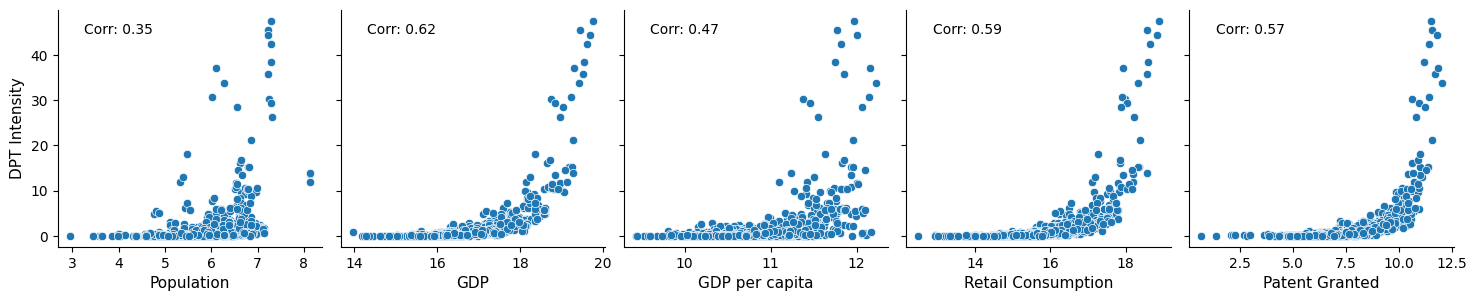

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

dfCity = pd.read_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/cityVariable.csv', header=0, index_col=0)
dfProgram_pct = pd.read_csv('D:/Dropbox/Dropbox/DPT_crime/Data/spatial_tech.csv', header=0, index_col=0)
# merge 'dfProgram_pct' with 'dfCity' on '城市_city' and 'year'
dfProgram_pct2 = pd.merge(dfProgram_pct, dfCity, on=['城市_city', 'year'], how='inner')
# rename column '年平均人口（万人）' to 'Population (in 10,000s)', '地区生产总值（当年价格（万元））' to 'GDP (in 10,000s)', '人均地区生产总值（元）' to 'GDP per capita', '社会消费品零售总额（亿元）' to 'Retail Consumption (in 100 million RMB)', '专利授权数(件)' to 'Patent Granted' 
dfProgram_pct2.rename(columns={'data_software_shareW_pct': 'DPT Share', 'data_software_valueW_pct': 'DPT Intensity', '年平均人口（万人）': 'Population', '地区生产总值（当年价格（万元））': 'GDP', '人均地区生产总值（元）': 'GDP per capita', '社会消费品零售总额（亿元）': 'Retail Consumption', '专利授权数(件)': 'Patent Granted'}, inplace=True)

# List of all variables including the new one
all_vars = ['DPT Intensity', 'Population', 'GDP', 'GDP per capita', 'Retail Consumption', 'Patent Granted']

# Calculate correlations for all variables
correlations = dfProgram_pct2[all_vars].corr()

# Generate the pairplot for the first (one) two rows only
g = sns.pairplot(dfProgram_pct2, y_vars=['DPT Intensity'], x_vars=all_vars[1:], kind='scatter', height=3)

# Annotate with the correlation coefficients and reduce label sizes
for i, row_axes in enumerate(g.axes):
    y_var = all_vars[i]
    for j, ax in enumerate(row_axes):
        x_var = all_vars[j + 1]  # Skip the first (one) two variables as they are on the y-axis
        corr = correlations.loc[y_var, x_var]
        ax.annotate(f"Corr: {corr:.2f}", xy=(0.1, 0.9), xycoords=ax.transAxes)
        ax.set_xlabel(x_var, fontsize=11)
        ax.set_ylabel(y_var, fontsize=11)

plt.show()


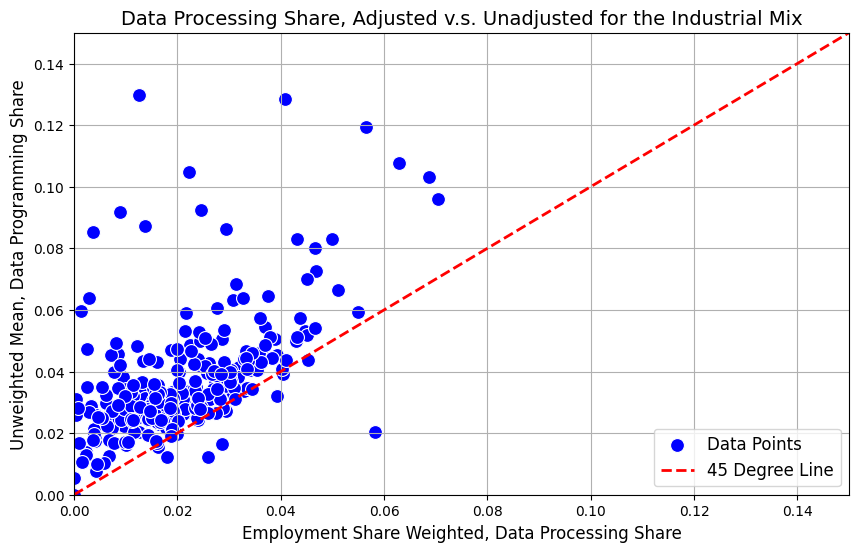

In [238]:
## Make a scatter plot of the adjusted and unadjusted share of data processing by city.

import matplotlib.pyplot as plt
import seaborn as sns

dfProgram_pc = pd.read_csv('D:/Dropbox/Dropbox/DPT_crime/Data/spatial_tech_pc.csv', header=0, index_col=0)

# Initialize your DataFrame dfProgram_pc here

plt.figure(figsize=(10, 6))
sns.scatterplot(x='data_software_shareW_pc', y='data_software_avg', data=dfProgram_pc, color='blue', s=100, label='Data Points')

# Titles and labels
plt.title('Data Processing Share, Adjusted v.s. Unadjusted for the Industrial Mix', fontsize=14)
plt.xlabel('Employment Share Weighted, Data Processing Share', fontsize=12)
plt.ylabel('Unweighted Mean, Data Programming Share', fontsize=12)

# Axis limits
plt.xlim(0, 0.15)
plt.ylim(0, 0.15)

# 45-degree line
plt.plot([0, 0.15], [0, 0.15], color='red', linewidth=2, linestyle='--', label='45 Degree Line')

# Legend and grid
plt.legend(fontsize=12, loc='lower right')
plt.grid(True)

plt.show()

#### Scatter plot of data processing `share` and `intensity` by city

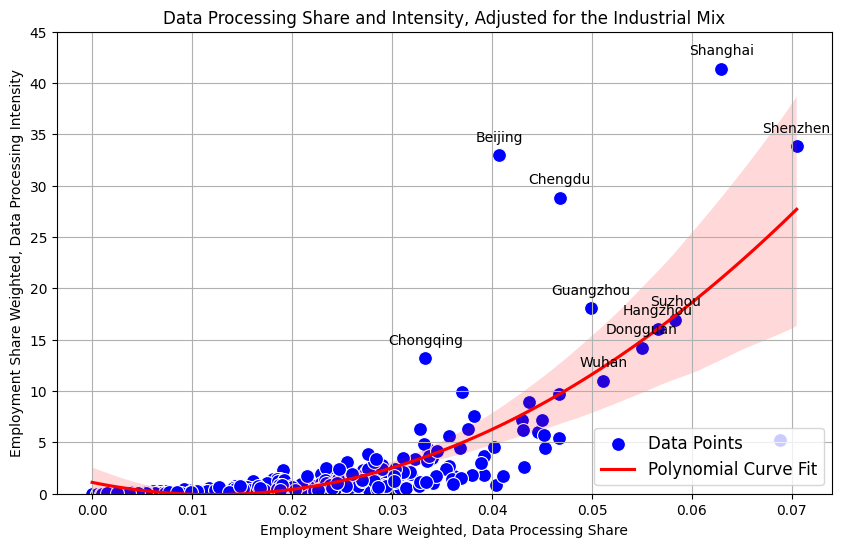

{'data_software_valueW_pc': 0.7133762348069943, 'data_software_shareW_pc': 0.32233614735816607}


In [9]:
## Make a scatter plot of the adjusted and unadjusted share of data processing by city.

import matplotlib.pyplot as plt
import seaborn as sns
from pypinyin import lazy_pinyin

# Heatmap of 'soc_t' by 'soc_code' and 'year'
# convert Chinese city names to pinyin
# Function to convert Chinese city names to pinyin, remove '市', and capitalize the first letter
# Be sure that '市' only appears at the end of city names and not in the middle, as this code removes all instances of '市' in the city name. 
# If '市' only appears at the end of city names, you could use city = city[:-1] instead of city = city.replace('市', '') to only remove the final character.
def convert_city_name(city):
    city = city.replace('市', '') # Remove '市'
    pinyin = ''.join(lazy_pinyin(city)) # Convert to pinyin
    pinyin = pinyin.capitalize() # Capitalize the first letter
    return pinyin

# Apply the function to the '城市_city' column
dfProgram_pc['城市_cityEng'] = dfProgram_pc['城市_city'].apply(convert_city_name)

# Initialize your DataFrame dfProgram_pc here
plt.figure(figsize=(10, 6))

# Filter cities with 'data_software_valueW_pc' higher than 15
high_value_cities = dfProgram_pc[dfProgram_pc['data_software_valueW_pc'] > 10]

# Scatter plot
sns.scatterplot(x='data_software_shareW_pc', y='data_software_valueW_pc', data=dfProgram_pc, 
                color='blue', s=100, label='Data Points')

# Fitting a polynomial curve (you can change the order parameter for higher or lower polynomials)
sns.regplot(x='data_software_shareW_pc', y='data_software_valueW_pc', data=dfProgram_pc, 
            scatter=False, color='red', label='Polynomial Curve Fit', order=2)

# Annotate cities with high 'data_software_valueW_pc'
for i, row in high_value_cities.iterrows():
    plt.annotate(row['城市_cityEng'], (row['data_software_shareW_pc'], row['data_software_valueW_pc']),
                 textcoords="offset points", xytext=(0,10), ha='center')

# Axis limits
plt.ylim(0, 45)

# Titles and labels
plt.title('Data Processing Share and Intensity, Adjusted for the Industrial Mix', fontsize=12)
plt.xlabel('Employment Share Weighted, Data Processing Share', fontsize=10)
plt.ylabel('Employment Share Weighted, Data Processing Intensity', fontsize=10)

# Legend and grid
plt.legend(fontsize=12, loc='lower right')
plt.grid(True)

plt.show()

def gini_coefficient(x):
    """Compute Gini coefficient of array of values"""
    x = np.array(x.dropna())  # Drop NaN values
    n = len(x)
    s = x.sum()
    r = np.argsort(np.argsort(-x))  # Calculates zero-based ranks
    return 1 - (2 * (r * x).sum() + s) / (n * s)

# Calculate Gini coefficients for each column
gini_coeffs = {
    'data_software_valueW_pc': gini_coefficient(dfProgram_pc['data_software_valueW_pc']),
    'data_software_shareW_pc': gini_coefficient(dfProgram_pc['data_software_shareW_pc'])
}

print(gini_coeffs)


#### Latex table record `Top 90 cities` in data processing intensity

In [ ]:
# Sorting the DataFrame by 'data_software_valueW_pc' and selecting the top 50
# Note: In the sample data there are only 5 rows, in your real DataFrame this should properly select the top 50
# keep '城市_city', 'data_software_shareW_pc', 'data_software_valueW_pc', and 'posting_count' 
dfProgram_pc1 = dfProgram_pc[['城市_cityEng', 'data_software_shareW_pc', 'data_software_valueW_pc']]
df_sorted = dfProgram_pc1.sort_values(by='data_software_valueW_pc', ascending=False).head(90)

# Split into two DataFrames: one for the top 25 and another for the next 25
df_top_30 = df_sorted.iloc[:30].reset_index(drop=True)
df_next_30 = df_sorted.iloc[30:60].reset_index(drop=True)
df_last_30 = df_sorted.iloc[60:].reset_index(drop=True)

# Rename the columns for the next 25 to avoid duplicate column names
df_next_30.columns = [col + '_next_25' for col in df_next_30.columns]
df_last_30.columns = [col + '_last_25' for col in df_last_30.columns]

# Concatenate the two DataFrames horizontally
df_combined = pd.concat([df_top_30, df_next_30, df_last_30], axis=1)

# Generate the LaTeX table
latex_table = df_combined.to_latex(index=False, float_format="%.3f")

print(latex_table)

## `Vertical connections caused by data programming technology`
- The masterdata frame for paper  `data technologies and vertical integration`

In [57]:
# Step1: Match parent firms with branches
# Keep required columns and unique rows, and rename columns all in one step
# Convert to string first to ensure that slicing works, then slice to get the year part
dfParent['注册年份_estiblishYear'] = dfParent['注册时间_estiblishTime'].astype(str).str[:4]
# Convert the sliced year to numeric, setting errors='coerce' to handle NaNs
dfParent['注册年份_estiblishYear'] = pd.to_numeric(dfParent['注册年份_estiblishYear'], errors='coerce')

dfParentSector = (
    dfParent[['parent_firm_id', '省份_province', '城市_city', '一级行业_categoryStrBig', '二级行业_categoryStrMiddle', 'majorInd_code', '注册年份_estiblishYear']]
    .drop_duplicates()
    .rename(columns={
        '省份_province': 'parent_province',
        '城市_city': 'parent_city',
        '一级行业_categoryStrBig': 'parent_sectorLvl1',
        '二级行业_categoryStrMiddle': 'parent_sectorLvl2',
        'majorInd_code': 'parent_majorInd_code',
        '注册年份_estiblishYear': 'parent_estiblishYear'
    })
)

# Merge with dfBranch, keeping only matched samples
dfParentSector = pd.merge(dfBranch, dfParentSector, on='parent_firm_id', how='inner')



# Step2: keep branches to be between 2000-2002 and 2017-2019 for the first difference estimation
# Convert date columns to year and update data types
dfParentSector['注册年份_estiblishYear'] = dfParentSector['注册时间_estiblishTime'].str[:4].astype(int)
dfParentSector['核准年份_approvedYear'] = dfParentSector['核准日期_approvedTime'].str[:4].astype(int)
# Dataframe `dfBranch3` records the total new (live) branches associated with the parent firm (origin).
# Filter dfParentSector for specific years and store in dfBranchSector
specific_years = [2017, 2018, 2019]
dfBranchSector = dfParentSector[dfParentSector['注册年份_estiblishYear'].isin(specific_years)]
# rename '注册年份_estiblishYear' to 'year'
dfBranchSector.rename(columns={'year': 'jobpost_year'}, inplace=True)
dfBranchSector.rename(columns={'注册年份_estiblishYear': 'year'}, inplace=True)



# Step4: generate data programming share based on previously generated dataframe 'dfInd1_t' 
# # aggregate the mean of 'indust1_t', 'indust1Branch_t', 'indust1Parent_t', 'indust1Local_t' by '一级行业_categoryStrBig' and '二级行业_categoryStrMiddle' 
# Group by multiple columns and apply custom aggregation functions
columns_to_aggregate = ['indust1_t', 'ERP_t', 'query_t', 'development_t', 'industry_t', 'foreign_t']
aggregations = {col: 'mean' for col in columns_to_aggregate}
dfInd1_t0 = dfInd1_t.groupby(['year', 'majorInd_code']).agg(aggregations).reset_index()

# rename 'majorInd_code' to 'parent_majorInd_code' 
dfInd1_t0.rename(columns={'majorInd_code': 'parent_majorInd_code'}, inplace=True)

# generate dataframe 'dfInd1_t01' from 'dfInd1_t0' and rename 'parent_majorInd_code' to 'majorInd_code' 
dfInd1_t01 = dfInd1_t0.rename(columns={'parent_majorInd_code': 'majorInd_code'})
# rename 'indust1_t' to 'indust1branch_t'
dfInd1_t01.rename(columns={'indust1_t': 'indust1branch_t', 'ERP_t': 'ERPbranch_t', 'query_t': 'querybranch_t', 'development_t': 'developmentbranch_t', 'industry_t': 'industrybranch_t', 'foreign_t': 'foreignbranch_t'}, inplace=True)



# Step5: generate 'dfBranchSector1' to record number of parent and branch firms
# Define custom aggregation functions
# Group by multiple columns and count unique 'parent_firm_id' and '公司ID'
dfBranchSector1 = dfBranchSector.groupby(
    ['year', 'parent_sectorLvl1', 'parent_sectorLvl2', 'parent_majorInd_code', 'majorInd_code', '一级行业_categoryStrBig', '二级行业_categoryStrMiddle']
).agg({
    'parent_firm_id': pd.Series.nunique,  # Count unique parent_firm_id
    '公司ID': pd.Series.nunique  # Count unique 公司ID
}).reset_index()

# Rename the columns for clarity
dfBranchSector1.columns = [
    'year', 'parent_sectorLvl1', 'parent_sectorLvl2', 'parent_majorInd_code', 
    'majorInd_code', '一级行业_categoryStrBig', '二级行业_categoryStrMiddle', 
    'num_parent_firm', 'num_branches'
]


# Step3: get the input-output link
# load input-output tables for merge
upwardVertical = pd.read_csv('G:/Data/job_posting/processed/estimation/upwardVertical_io.csv', encoding='utf_8_sig')
downwardVertical = upwardVertical.copy()
# Swap values between 'majorInd_code' and 'parent_majorInd_code'
downwardVertical['majorInd_code'], downwardVertical['parent_majorInd_code'] = downwardVertical['parent_majorInd_code'], downwardVertical['majorInd_code']
# Rename the 'upwardVertical' column to 'downwardVertical'
downwardVertical.rename(columns={'upwardVertical': 'downwardVertical'}, inplace=True)


# Step 7: merge and produce the final dataframe
# merge 'dfBranchSector2' with 'dfBranchSector' on 'post_dpt', 'parent_sectorLvl1', 'parent_sectorLvl2', 'parent_majorInd_code', keep all observations in 'dfBranchSector'
# Merge 'upwardVertical' with 'dfBranchSector' on 'majorInd_code' and 'parent_majorInd_code', keeping only matched samples and from 'dfBranchSector' 
dfBranchSector3 = pd.merge(dfBranchSector1, upwardVertical, 
                     on=['majorInd_code', 'parent_majorInd_code'], 
                     how='outer')
dfBranchSector3 = pd.merge(dfBranchSector3, downwardVertical, 
                     on=['majorInd_code', 'parent_majorInd_code'], 
                     how='outer')

# Identify the rows where 'year' is NaN
mask = dfBranchSector3['year'].isna()
# Create duplicates of these rows
duplicated_df = dfBranchSector3[mask].copy()
# Assign the values 2017, 2018, and 2019 to 'year' in the original and duplicated dataframes
dfBranchSector3.loc[mask, 'year'] = 2017
duplicated_df1 = duplicated_df.copy()
duplicated_df1['year'] = 2018
duplicated_df2 = duplicated_df.copy()
duplicated_df2['year'] = 2019

# Concatenate the original dataframe with the duplicates
dfBranchSector3 = pd.concat([dfBranchSector3, duplicated_df1, duplicated_df2], ignore_index=True)
dfBranchSector3 = pd.merge(dfBranchSector3, dfInd1_t0, how='left', on=['year', 'parent_majorInd_code'])
dfBranchSector3 = pd.merge(dfBranchSector3, dfInd1_t01, how='left', on=['year', 'majorInd_code'])

# Merge with industry characteristics: age 
# subset column 'majorInd_code' and '注册时间_estiblishTime' from 'filtered_dataframe2' 
filtered_dataframeNew = dfBranchSector[['majorInd_code', 'year', 'parent_estiblishYear']] 
# Compute the mean age in place
filtered_dataframeNew['mean_estiblishYear'] = filtered_dataframeNew.groupby(['majorInd_code', 'year'])['parent_estiblishYear'].transform('mean')
# Create df_age by dropping duplicates
df_age = filtered_dataframeNew[['majorInd_code', 'year', 'mean_estiblishYear']].drop_duplicates().reset_index(drop=True)
# rename column '注册年份_estiblishYear' to 'age' 
df_age.rename(columns={'mean_estiblishYear': 'age_j', 'majorInd_code': 'parent_majorInd_code'}, inplace=True)
df_age_branch = df_age.copy()
# rename column 'age' to 'age_branch', rename column 'parent_majorInd_code' to 'majorInd_code' 
df_age_branch.rename(columns={'age_j': 'age_k', 'parent_majorInd_code': 'majorInd_code'}, inplace=True)

dfBranchSector3 = pd.merge(dfBranchSector3, df_age, how='left', on=['year', 'parent_majorInd_code'])
dfBranchSector3 = pd.merge(dfBranchSector3, df_age_branch, how='left', on=['year', 'majorInd_code'])

# rename '注册年份_estiblishYear' to 'year', rename 'parent_province' to '省份_province', rename 'parent_city' to '城市_city', rename 'parent_firm_id' to 'branchCount_pct'
dfBranchSector3.rename(columns={'parent_sectorLvl1': '一级行业_parent', 'parent_sectorLvl2': '二级行业_parent', 'majorInd_code': 'branch_majorInd_code', 
                               '一级行业_categoryStrBig': '一级行业_branch', '二级行业_categoryStrMiddle': '二级行业_branch'}, inplace=True)
dfBranchSector3.head()

# export to 'D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/' 
#dfBranchSector3.to_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/dfBranchSector3.csv', index=False, encoding='utf_8_sig')

C:\Users\DELL\AppData\Local\Temp\ipykernel_38052\1886506165.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfParent['注册年份_estiblishYear'] = dfParent['注册时间_estiblishTime'].astype(str).str[:4]
C:\Users\DELL\AppData\Local\Temp\ipykernel_38052\1886506165.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfParent['注册年份_estiblishYear'] = pd.to_numeric(dfParent['注册年份_estiblishYear'], errors='coerce')
C:\Users\DELL\AppData\Local\Temp\ipykernel_38052\1886506165.py:35: SettingWithCopyWarning: 
A value is tryin

,year,一级行业_parent,二级行业_parent,parent_majorInd_code,branch_majorInd_code,一级行业_branch,二级行业_branch,num_parent_firm,num_branches,upwardVertical,...,industry_t,foreign_t,indust1branch_t,ERPbranch_t,querybranch_t,developmentbranch_t,industrybranch_t,foreignbranch_t,age_j,age_k
0,2017.0,农、林、牧、渔业,农业,1.0,1.0,农、林、牧、渔业,农业,637.0,1193.0,0.991,...,0.005724,0.022034,0.039243,0.018582,0.003065,0.014601,0.005724,0.022034,2012.931760,2012.931760
1,2018.0,农、林、牧、渔业,农业,1.0,1.0,农、林、牧、渔业,农业,627.0,1056.0,0.991,...,0.005780,0.020992,0.032362,0.012735,0.004160,0.013497,0.005780,0.020992,2014.287116,2014.287116
2,2019.0,农、林、牧、渔业,农业,1.0,1.0,农、林、牧、渔业,农业,253.0,384.0,0.991,...,0.005439,0.016612,0.025726,0.010952,0.003197,0.009114,0.005439,0.016612,2014.712785,2014.712785
3,2017.0,农、林、牧、渔业,林业,2.0,1.0,农、林、牧、渔业,农业,35.0,41.0,0.000,...,0.017535,0.028636,0.039243,0.018582,0.003065,0.014601,0.005724,0.022034,2010.268817,2012.931760
4,2018.0,农、林、牧、渔业,林业,2.0,1.0,农、林、牧、渔业,农业,25.0,25.0,0.000,...,0.012796,0.021975,0.032362,0.012735,0.004160,0.013497,0.005780,0.020992,2009.569132,2014.287116


#### The compositional share of data tech by industry (only using parent firm's data)

C:\Users\DELL\AppData\Local\Temp\ipykernel_38052\3274981167.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfBranchSector4.drop_duplicates(subset=['year', 'parent_majorInd_code'], inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_38052\3274981167.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfBranchSector4.sort_values(by=['year', 'parent_majorInd_code'], inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_38052\3274981167.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in

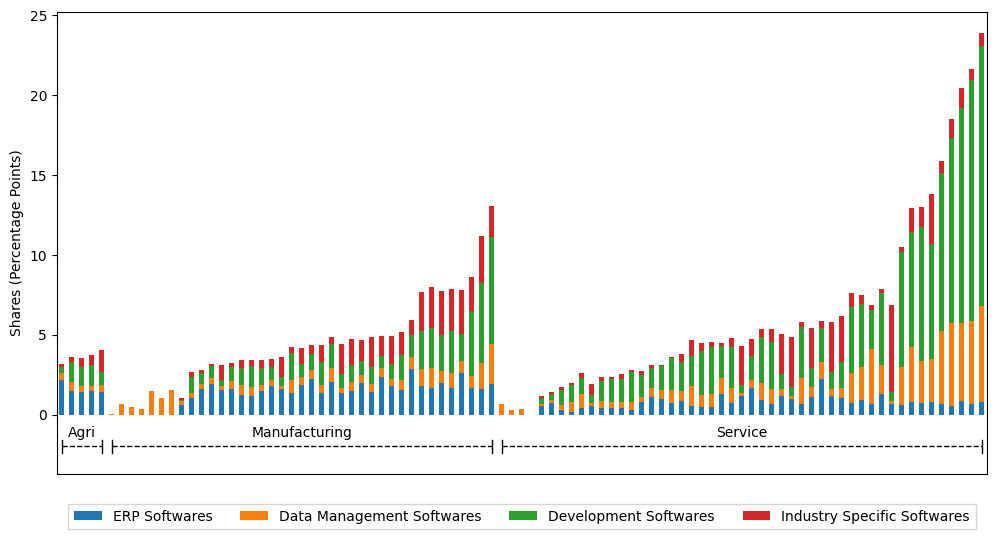

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the dfBranchSector3 from the CSV (assuming this is done)
# dfBranchSector3 = pd.read_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/dfBranchSector3.csv', header=0, index_col=0)

# Filter columns
dfBranchSector4 = dfBranchSector3[['year', '一级行业_parent', '二级行业_parent', 'parent_majorInd_code', 'indust1_t', 'ERP_t', 'query_t', 'development_t', 'industry_t', 'foreign_t']]

# Drop duplicates and sort by year and parent_majorInd_code
dfBranchSector4.drop_duplicates(subset=['year', 'parent_majorInd_code'], inplace=True)
dfBranchSector4.sort_values(by=['year', 'parent_majorInd_code'], inplace=True)

# Multiply values by 100
dfBranchSector4[['indust1_t', 'ERP_t', 'query_t', 'development_t', 'industry_t', 'foreign_t']] *= 100

# Fill missing values
df_filled = dfBranchSector4.fillna(0)

# Create a new column 'sector' based on the categorization of 'parent_majorInd_code' into agri, manufacturing, and service
def assign_sector(code):
    if 0 <= code <= 5:  # 0-5 for Agri
        return 'Agri'
    elif 6 <= code <= 44:  # 6-44 for Manufacturing
        return 'Manufacturing'
    else:  # Everything else for Service
        return 'Service'


df_filled['sector'] = df_filled['parent_majorInd_code'].apply(assign_sector)

# Calculate averages and reset the index
averages = df_filled.groupby(['sector', 'parent_majorInd_code'])[['indust1_t', 'ERP_t', 'query_t', 'development_t', 'industry_t']].mean().reset_index()

# Rename columns for better presentation
averages.rename(columns={'ERP_t': 'ERP Softwares', 'query_t': 'Data Management Softwares', 
                         'development_t': 'Development Softwares', 'industry_t': 'Industry Specific Softwares'}, inplace=True)

# Sort within each sector by 'indust1_t', ensuring the order of sectors is preserved as 'Agri', 'Manufacturing', 'Service'
sector_order = ['Agri', 'Manufacturing', 'Service']
averages['sector'] = pd.Categorical(averages['sector'], categories=sector_order, ordered=True)

# Now, we need to sort within each sector by 'indust1_t'
averages = averages.sort_values(by=['sector', 'indust1_t'], ascending=[True, True])

# Separate data for each sector to maintain the order and correct within-sector ranking
agri_data = averages[averages['sector'] == 'Agri']
manufacturing_data = averages[averages['sector'] == 'Manufacturing']
service_data = averages[averages['sector'] == 'Service']

# Concatenate the data back in the correct order (Agri, Manufacturing, Service)
sorted_averages = pd.concat([agri_data, manufacturing_data, service_data])

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
sorted_averages.set_index('parent_majorInd_code')[['ERP Softwares', 'Data Management Softwares', 'Development Softwares', 'Industry Specific Softwares']].plot(kind='bar', stacked=True, ax=ax)

# Remove the x-axis completely
ax.xaxis.set_visible(False)

# Custom function to draw curly brackets with text inside the figure
def draw_line_with_text(ax, xspan, y, height, text, vertical_lines):
    """Draws an annotated straight line on the axes with text inside the figure."""
    xmin, xmax = xspan
    # Draw base line
    ax.plot([xmin, xmax], [y, y], color='black', linestyle='dashed', linewidth=1)  

    # Draw small vertical lines
    for x in vertical_lines:
        if xmin <= x <= xmax:  # Only draw if x is within the span
            ax.plot([x, x], [y - height * 0.2, y + height * 0.2], color='black', linewidth=1)

    # Adding text above the line
    ax.text((xmin + xmax) / 2, y + height * 0.2, text, ha='center', va='bottom', fontsize=10)

# Count the number of rows for each sector
agri_count = len(agri_data)
manufacturing_count = len(manufacturing_data)
service_count = len(service_data)

# Fixed height for brackets
brace_height = 2

# Define the positions of the sectors based on the number of entries
agri_range = (0, agri_count - 1)
manufacturing_range = (agri_count, agri_count + manufacturing_count - 1)
service_range = (agri_count + manufacturing_count, agri_count + manufacturing_count + service_count - 1)

# Draw curly brackets for each sector
draw_line_with_text(ax, agri_range, -brace_height, brace_height, 'Agri', list(agri_range))
draw_line_with_text(ax, manufacturing_range, -brace_height, brace_height, 'Manufacturing', list(manufacturing_range))
draw_line_with_text(ax, service_range, -brace_height, brace_height, 'Service', list(service_range))

# Move the legend outside the figure, in 1 row
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), fancybox=False, shadow=False, ncol=len(sorted_averages.columns)-1)

plt.title('')
plt.ylabel('Shares (Percentage Points)')
plt.xlabel('Ranked by Shares Within Sectors')

plt.show()

# Generate the Bartik instruments for industrial analysis

In [ ]:
import os
import pandas as pd
import gc
import numpy as np

filtered_dataframe2 = pd.read_csv('G:/Data/job_posting/processed/estimation/spatial_tech_diffusion5.csv', encoding='utf-8')

# Step 1: Filter out rows with missing values
df_filtered = filtered_dataframe2.dropna(subset=['year', 'soc_code', 'majorInd_code', 'posting_count'])
df_filtered.rename(columns={'year': 'jobpost_year'}, inplace=True)

# Step 2: Aggregate at 'jobpost_year', 'soc_code', 'majorInd_code' level
df_agg1 = df_filtered.groupby(['jobpost_year', 'soc_code', 'majorInd_code']).agg({'posting_count': 'sum'}).reset_index()
# Step 3: Aggregate at 'jobpost_year', 'majorInd_code' level
df_agg2 = df_filtered.groupby(['jobpost_year', 'majorInd_code']).agg({'posting_count': 'sum'}).reset_index()

# Step 4: Merge the two aggregated DataFrames and calculate 'laborShare'
df_merged = pd.merge(df_agg1, df_agg2, on=['jobpost_year', 'majorInd_code'], suffixes=('_level1', '_level2'))
df_merged['laborShare'] = df_merged['posting_count_level1'] / df_merged['posting_count_level2']
# convert 'soc_code' to 'int' 
df_merged['soc_code'] = df_merged['soc_code'].astype(int)
# The df_merged DataFrame now contains the aggregated data with 'laborShare'
df_merged.head()



# load dataframe 'dfPosting_comp' from China_US_comparison.ipynb
dfPosting_comp = pd.read_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/dfPosting_shiftshare.csv', encoding='utf-8-sig')
# keep 'Commodity Title' with values end with 'China_0'  
dfPosting_comp = dfPosting_comp[dfPosting_comp['Commodity Title'].str.endswith('China_0')]
# remove the string 'China_0' from 'Commodity Title'
dfPosting_comp['Commodity Title'] = dfPosting_comp['Commodity Title'].str.replace('_China_0', '')


# Given mapping of commodity names to class titles
commodity_to_class = {
    'Web platform development software': 'Development software',
    'Data base management system software': 'Data management and query software',
    'Data base user interface and query software': 'Data management and query software',
    'Development environment software': 'Development software',
    'Business intelligence and data analysis software': 'Data management and query software',
    'Enterprise application integration software': 'Development software',
    'Computer aided design CAD software': 'Industry specific software',
    'Object or component oriented development software': 'Development software',
    'Configuration management software': 'Development software',
    'Medical software': 'Industry specific software',
    'Object oriented data base management software': 'Data management and query software',
    'Analytical or scientific software': 'Industry specific software',
    'Metadata management software': 'Data management and query software',
    'Program testing software': 'Development software',
    'Enterprise resource planning ERP software': 'Finance accounting and enterprise resource planning ERP software',
    'Data base reporting software': 'Data management and query software',
    'Accounting software': 'Finance accounting and enterprise resource planning ERP software'
}

# Map 'Commodity Title' to classes
dfPosting_comp['Class'] = dfPosting_comp['Commodity Title'].map(commodity_to_class)

# Group by 'Class' and 'Code', then sum 'PercentageSum'
df_collapsed = dfPosting_comp.groupby(['Class', 'Code'])['PercentageSum'].sum().reset_index()
# Pivot the DataFrame
df_pivoted = df_collapsed.pivot(index='Code', columns='Class', values='PercentageSum').reset_index()

# keep first 7 characters in 'Code' column
df_pivoted['soc_code'] = df_pivoted['Code'].str[:7]
# remove '-' in column 'soc_code' 
df_pivoted['soc_code'] = df_pivoted['soc_code'].str.replace('-', '')
# replace the last digit in column 'soc_code' to be 0
df_pivoted['soc_code'] = df_pivoted['soc_code'].str[:-1] + '0'

# replace missing values in 'Development software', 'Data management and query software', 'Industry specific software', 'Finance accounting and enterprise resource planning ERP software' to 0
df_pivoted['Development software'] = df_pivoted['Development software'].fillna(0)
df_pivoted['Data management and query software'] = df_pivoted['Data management and query software'].fillna(0)
df_pivoted['Industry specific software'] = df_pivoted['Industry specific software'].fillna(0)
df_pivoted['Finance accounting and enterprise resource planning ERP software'] = df_pivoted['Finance accounting and enterprise resource planning ERP software'].fillna(0)

# generate column 'bartikus_ind' to sum values in 'Development software', 'Data management and query software', 'Industry specific software', 'Finance accounting and enterprise resource planning ERP software'
df_pivoted['PercentageUS'] = df_pivoted['Development software'] + df_pivoted['Data management and query software'] + df_pivoted['Industry specific software'] + df_pivoted['Finance accounting and enterprise resource planning ERP software']

df_pivoted.rename(columns={'Finance accounting and enterprise resource planning ERP software': 'ERP', 'Data management and query software': 'query', 'Development software': 'development', 'Industry specific software': 'industry'}, inplace=True)

# List of columns to calculate the mean
columns_to_mean = ['query', 'development', 'ERP', 'industry', 'PercentageUS']
# Group by 'soc_code' and calculate the mean of the specified columns
df_pivoted = df_pivoted.groupby('soc_code')[columns_to_mean].mean().reset_index()
df_pivoted['soc_code'] = df_pivoted['soc_code'].astype(int)
# export the data for later use: shift-share IV test
df_pivoted.to_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/df_pivoted.csv', index=False, encoding='utf_8_sig')

# merge 'df_merged' and 'dfPosting_comp' on 'soc_code'
df_merged1 = pd.merge(df_merged, df_pivoted, how='left', on='soc_code')
# export the data for later use: shift-share IV test
df_merged1.to_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/bartik_industrial_test.csv', index=False, encoding='utf_8_sig')

# Calculate the sum of the products for each group
def custom_aggregation(df):
    df['query_US'] = df['laborShare'] * df['query']
    df['development_US'] = df['laborShare'] * df['development']
    df['ERP_US'] = df['laborShare'] * df['ERP']
    df['industry_US'] = df['laborShare'] * df['industry']
    df['Product_US'] = df['laborShare'] * df['PercentageUS']
    return df[['query_US', 'development_US', 'ERP_US', 'industry_US', 'Product_US']].sum()

# Perform the aggregation
agg_df = df_merged1.groupby(['jobpost_year', 'majorInd_code']).apply(custom_aggregation).reset_index()
# Rename the columns
agg_df.columns = ['year', 'parent_majorInd_code', 'query_US', 'development_US', 'ERP_US', 'industry_US', 'BartikUS_ind']
agg_df.to_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/bartik_industrial.csv', index=False, encoding='utf_8_sig')

C:\Users\DELL\AppData\Local\Temp\ipykernel_31376\3992001703.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.rename(columns={'year': 'jobpost_year'}, inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_31376\3992001703.py:105: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_df = df_merged1.groupby(['jobpost_year', 'majorInd_code']).apply(custom_aggregation).reset_index()


#### Figure of data processing technologies by occupation and industry in China and US

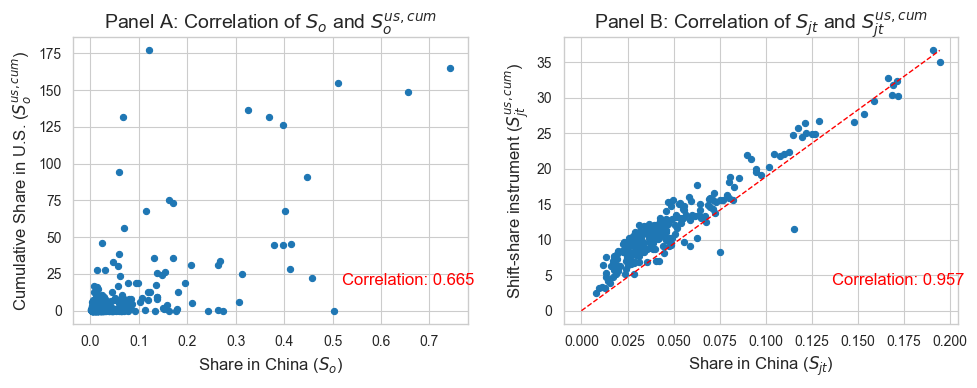

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Use a “paper” context with a bit of font scaling
sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid")

# — your existing data‐prep steps here —
df_agg0 = (
    df_filtered
    .groupby('soc_code')
    .agg({'data_software': 'mean'})
    .reset_index()
)
df_agg0['soc_code'] = df_agg0['soc_code'].astype(int)
df_pivoted2 = df_pivoted[['soc_code', 'PercentageUS']]
df_merged0 = pd.merge(df_agg0, df_pivoted2, on='soc_code')

correlation1 = df_merged0['data_software'].corr(df_merged0['PercentageUS'])

dfPosting_ind = pd.read_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/in_ivvalid.csv', encoding='utf-8-sig')
correlation2 = dfPosting_ind['indust1_t'].corr(dfPosting_ind['bartikus_ind'])

# 2. Shrink the overall canvas so it’ll fit in two‐column format
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Panel A
axes[0].scatter(
    df_merged0['data_software'], 
    df_merged0['PercentageUS'],
    s=20
)
axes[0].text(
    0.7 * df_merged0['data_software'].max(),
    0.1 * df_merged0['PercentageUS'].max(),
    f"Correlation: {correlation1:.3f}",
    fontsize=12, color='red'
)
axes[0].set_xlabel(r'Share in China ($S_{o}$)', fontsize=12)
axes[0].set_ylabel(r'Cumulative Share in U.S. ($S_{o}^{us,cum}$)', fontsize=12)
axes[0].set_title(
    r'Panel A: Correlation of $S_{o}$ and $S_{o}^{us,cum}$',
    fontsize=14
)
axes[0].tick_params(axis='both', labelsize=10)
axes[0].grid(True)

# Panel B
axes[1].scatter(
    dfPosting_ind['indust1_t'], 
    dfPosting_ind['bartikus_ind'],
    s=20
)
axes[1].plot(
    [0, dfPosting_ind['indust1_t'].max()],
    [0, dfPosting_ind['bartikus_ind'].max()],
    'r--', linewidth=1
)
axes[1].text(
    0.7 * dfPosting_ind['indust1_t'].max(),
    0.1 * dfPosting_ind['bartikus_ind'].max(),
    f"Correlation: {correlation2:.3f}",
    fontsize=12, color='red'
)
axes[1].set_xlabel(r'Share in China ($S_{jt}$)', fontsize=12)
axes[1].set_ylabel(r'Shift-share instrument ($S_{jt}^{us,cum}$)', fontsize=12)
axes[1].set_title(
    r'Panel B: Correlation of $S_{jt}$ and $S_{jt}^{us,cum}$',
    fontsize=14
)
axes[1].tick_params(axis='both', labelsize=10)
axes[1].grid(True)

# 3. Tight layout to minimize wasted margin
plt.tight_layout(pad=1.0)
plt.show()


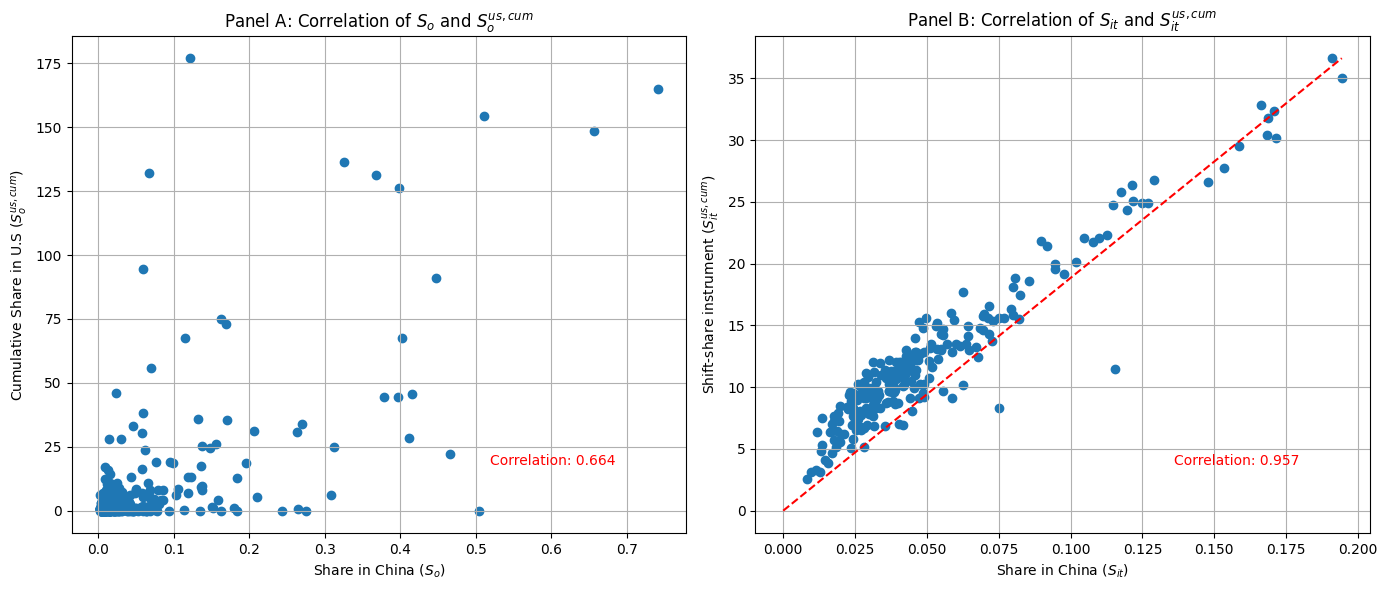

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# ## Panel A figure
# # Step 1: Filter out rows with missing values
# df_agg0 = df_filtered.groupby(['soc_code']).agg({'data_software': 'mean'}).reset_index()
# # convert 'soc_code' to 'int' 
# df_agg0['soc_code'] = df_agg0['soc_code'].astype(int)

# # keep columns soc_code, PercentageUS in 'df_pivoted' 
# df_pivoted2 = df_pivoted[['soc_code', 'PercentageUS']]

# # merge 'df_agg0' and 'df_pivoted2' on 'soc_code'
# df_merged0 = pd.merge(df_agg0, df_pivoted2, how='inner', on='soc_code')
# # Add a 45-degree line for reference
# max_x_value = df_merged0['data_software'].max()
# max_y_value = df_merged0['PercentageUS'].max()

# # Your modified code for the first plot
# correlation1 = df_merged0['data_software'].corr(df_merged0['PercentageUS'])

# ## Panel B figure
# dfPosting_ind = pd.read_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/in_ivvalid.csv', encoding='utf-8-sig')

# # Prepare data for the second plot
# correlation2 = dfPosting_ind['indust1_t'].corr(dfPosting_ind['bartikus_ind'])

# # Initialize a 1x2 grid of subplots
# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# # Plot for df_merged0
# axes[0].scatter(df_merged0['data_software'], df_merged0['PercentageUS'])
# #axes[0].plot([0, max_x_value], [0, max_y_value], 'r--')  # 45-degree line
# axes[0].text(max_x_value * 0.7, max_y_value * 0.1, f"Correlation: {correlation1:.3f}", fontsize=10, color='red')
# axes[0].set_xlabel('Share in China ($S_{o}$)')
# axes[0].set_ylabel('Cumulative Share in U.S ($S_{o}^{us,cum}$)')
# axes[0].set_title('Panel A: Correlation of $S_{o}$ and $S_{o}^{us,cum}$')  # Replace with your desired title
# axes[0].grid(True)

# # Plot for dfPosting_ind
# max_x_value_ind = dfPosting_ind['indust1_t'].max()
# max_y_value_ind = dfPosting_ind['bartikus_ind'].max()
# axes[1].scatter(dfPosting_ind['indust1_t'], dfPosting_ind['bartikus_ind'])
# axes[1].plot([0, max_x_value_ind], [0, max_y_value_ind], 'r--')  # 45-degree line
# axes[1].text(max_x_value_ind * 0.7, max_y_value_ind * 0.1, f"Correlation: {correlation2:.3f}", fontsize=10, color='red')
# axes[1].set_xlabel('Share in China ($S_{it}$)')
# axes[1].set_ylabel('Shift-share instrument ($S_{it}^{us,cum}$)')
# axes[1].set_title('Panel B: Correlation of $S_{it}$ and $S_{it}^{us,cum}$')  # Replace with your desired title
# axes[1].grid(True)

# # Adjust layout and display the combined plot
# plt.tight_layout()
# plt.show()

#### For Chinese paper `data technologies and crime` to show the data technology by occupation, a practice for the Bartik instruments

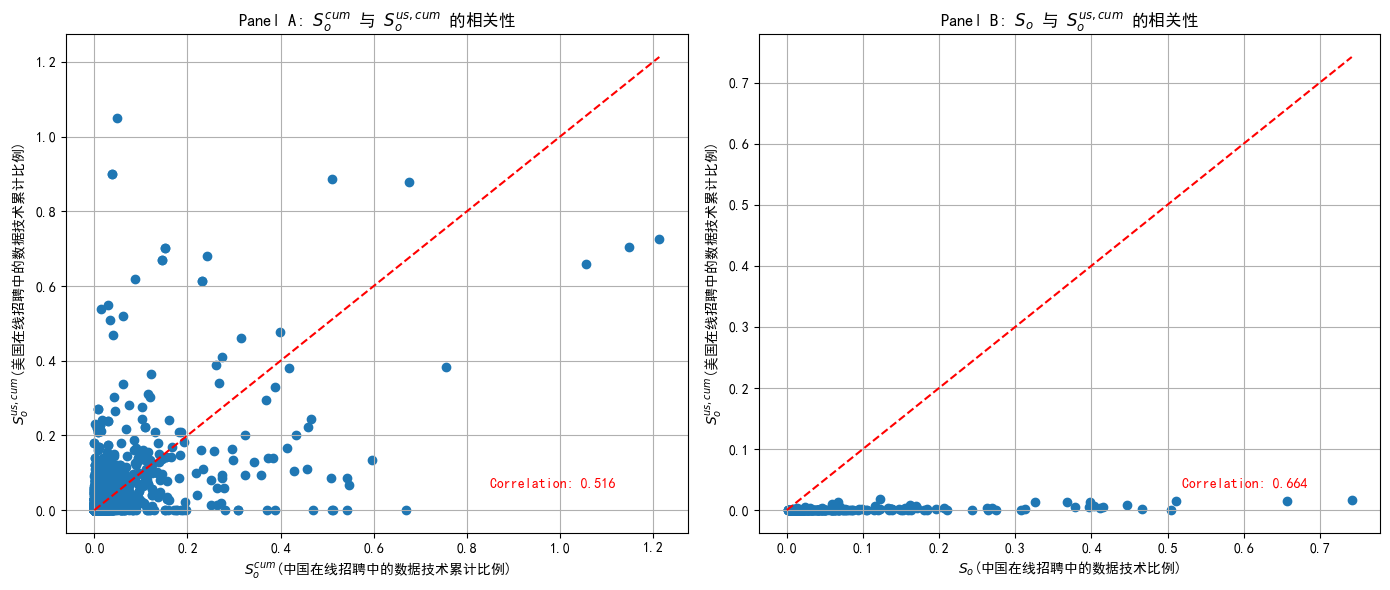

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Read data from the CSV files
dfPosting_comp = pd.read_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/dfPosting_comp.csv', encoding='utf-8-sig')
df_pivoted = pd.read_csv('D:/Dropbox/Dropbox/Paper with Yao-yu/Spatial Data Programming/Data/df_pivoted.csv', encoding='utf-8-sig')

# Adjust 'PercentageSumCN' and 'PercentageSumUS' by dividing by 100
dfPosting_comp['PercentageSumCN'] /= 100
dfPosting_comp['PercentageSumUS'] /= 100

# Initialize a 1x2 grid of subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False  # Ensure minus signs are displayed correctly

# --- Scatter Plot for the First Column (Panel A) ---
# Calculate the correlation for the scatter plot
original_corr = dfPosting_comp['PercentageSumCN'].corr(dfPosting_comp['PercentageSumUS'])

# Generate the scatter plot in the first subplot
axes[0].scatter(dfPosting_comp['PercentageSumCN'], dfPosting_comp['PercentageSumUS'], label='累计数据技术应用比例')

# Add a 45-degree line for reference in the scatter plot
max_value_A = max(dfPosting_comp['PercentageSumCN'].max(), dfPosting_comp['PercentageSumUS'].max())
axes[0].plot([0, max_value_A], [0, max_value_A], '--', color='red', label='45-degree line')

# Add text to indicate the correlation value in the scatter plot
axes[0].text(max_value_A*0.7, max_value_A*0.05, f"Correlation: {original_corr:.3f}", fontsize=10, color='red')

# Add titles and labels to the scatter plot
axes[0].set_title('Panel A: $S_{o}^{cum}$ 与 $S_{o}^{us,cum}$ 的相关性')
axes[0].set_xlabel('$S_{o}^{cum}$(中国在线招聘中的数据技术累计比例)')
axes[0].set_ylabel('$S_{o}^{us,cum}$(美国在线招聘中的数据技术累计比例)')
axes[0].grid(True)

# --- Scatter Plot for the Second Column (Panel B) ---
df_merged0['PercentageUS'] /= 100
# Calculate the correlation for df_merged0
correlation1 = df_merged0['data_software'].corr(df_merged0['PercentageUS'])

# Scatter plot for df_merged0
axes[1].scatter(df_merged0['data_software'], df_merged0['PercentageUS'])

# Add a 45-degree line in the second subplot (Panel B)
max_value_B = max(df_merged0['data_software'].max(), df_merged0['PercentageUS'].max())
axes[1].plot([0, max_value_B], [0, max_value_B], '--', color='red', label='45-degree line')

# Add text to indicate the correlation value in the second subplot
axes[1].text(max_value_B * 0.7, max_value_B * 0.05, f"Correlation: {correlation1:.3f}", fontsize=10, color='red')

# Add titles and labels to the second scatter plot
axes[1].set_title('Panel B: $S_{o}$ 与 $S_{o}^{us,cum}$ 的相关性')
axes[1].set_xlabel('$S_{o}$(中国在线招聘中的数据技术比例)')
axes[1].set_ylabel('$S_{o}^{us,cum}$(美国在线招聘中的数据技术累计比例)')
axes[1].grid(True)

# Show the plot
plt.tight_layout()
plt.show()

#### Generate variables for the Hull's Bartik IV test (for industrial analysis)

In [ ]:
# generate technologies measure for industries (from technology yearbook)
df_tech1 = pd.read_csv('C:/Users/DELL/Desktop/中国科技数据库_2017.csv', encoding='utf-8')
df_tech1['二级行业_categoryStrMiddle'] = df_tech1['二级行业_categoryStrMiddle'].replace(['广播、电视、电影和影视录音制作业', '建筑装饰和其他建筑业', '仓储业', '装卸搬运和运输代理业', 
                                                '农、林、牧、渔服务业', '开采辅助活动', '石油加工、炼焦和核燃料加工业'], ['广播、电视、电影和录音业', '建筑装饰、装修和其他建筑业', '装卸搬运和仓储业', 
                                                '多式联运和运输代理业', '农、林、牧、渔专业及辅助性活动', '开采专业及辅助性活动', '石油、煤炭及其他燃料加工业'])
df_tech2 = pd.read_csv('C:/Users/DELL/Desktop/中国科技数据库_201819.csv', encoding='utf-8')
# merge 'df_tech1' with 'df_tech2' on 'Unnamed: 0' amd '二级行业_categoryStrMiddle' 
df_tech = pd.merge(df_tech1, df_tech2, on=['Unnamed: 0', '二级行业_categoryStrMiddle'], how='outer')
# Reshape the DataFrame using melt
melted_df = pd.melt(df_tech, id_vars=['Unnamed: 0', '二级行业_categoryStrMiddle'], var_name='year', value_name='value')
# Pivot to get the desired shape
reshaped_df = melted_df.pivot(index=['二级行业_categoryStrMiddle', 'year'], columns='Unnamed: 0', values='value').reset_index()

# merge with 'dfInd1_t' on '二级行业_categoryStrMiddle', keep all observations in 'dfInd1_t'
reshaped_df = pd.merge(reshaped_df, dfInd2, how='left', on='二级行业_categoryStrMiddle')
# remove columns 'majorInd_name', '二级行业_categoryStrMiddle'
reshaped_df.drop(['majorInd_name', '二级行业_categoryStrMiddle'], axis=1, inplace=True)
reshaped_df.to_csv('C:/Users/DELL/Desktop/df_tech.csv', index=False, encoding='utf_8_sig')

In [ ]:
# Generate the lag measures for 1990, 1995 and 2000

# Filter dfParentSector for specific years and store in dfBranchSector
specific_years = [1990, 1995, 2000]
dfBranchRob = dfParentSector[dfParentSector['注册年份_estiblishYear'].isin(specific_years)]
# rename '注册年份_estiblishYear' to 'year'
dfBranchRob.rename(columns={'year': 'jobpost_year'}, inplace=True)
dfBranchRob.rename(columns={'注册年份_estiblishYear': 'year'}, inplace=True)

# Define custom aggregation functions
# Group by multiple columns and count unique 'parent_firm_id' and '公司ID'
dfBranchRob1 = dfBranchRob.groupby(
    ['year', 'parent_sectorLvl1', 'parent_sectorLvl2', 'parent_majorInd_code', 'majorInd_code', '一级行业_categoryStrBig', '二级行业_categoryStrMiddle']
).agg({
    'parent_firm_id': pd.Series.nunique,  # Count unique parent_firm_id
    '公司ID': pd.Series.nunique  # Count unique 公司ID
}).reset_index()

# Rename the columns for clarity
dfBranchRob1.columns = [
    'year', 'parent_sectorLvl1', 'parent_sectorLvl2', 'parent_majorInd_code', 
    'majorInd_code', '一级行业_categoryStrBig', '二级行业_categoryStrMiddle', 
    'num_parent_firm', 'num_branches'
]

# convert 'majorInd_code', 'parent_majorInd_code' to 'int'
dfBranchRob1['majorInd_code'] = dfBranchRob1['majorInd_code'].astype(int)
dfBranchRob1['parent_majorInd_code'] = dfBranchRob1['parent_majorInd_code'].astype(int)
# keep columns 'year' 'parent_majorInd_code', 'majorInd_code', 'num_parent_firm', 'num_branches'
dfBranchRob1 = dfBranchRob1[['year', 'parent_majorInd_code', 'majorInd_code', 'num_parent_firm', 'num_branches']]

# Calculate the 'tem' column as the total of 'num_branches' grouped by 'year' and 'parent_majorInd_code'
dfBranchRob1['tem'] = dfBranchRob1.groupby(['year', 'parent_majorInd_code'])['num_branches'].transform('sum')
# Calculate 'vertshare' as the mean of 'tem' grouped by 'year' and 'parent_majorInd_code'
dfBranchRob1['vertshare'] = dfBranchRob1.groupby(['year', 'parent_majorInd_code'])['tem'].transform('mean')
# Replace 'vertshare' with 'num_branches' divided by 'vertshare'
dfBranchRob1['vertshare'] = dfBranchRob1['num_branches'] / dfBranchRob1['vertshare']

# Drop the unnecessary columns
dfBranchRob1.drop(['tem', 'num_parent_firm', 'num_branches'], axis=1, inplace=True)
# Reshape the DataFrame using pivot
dfBranchRob1_RS = dfBranchRob1.pivot(index=['parent_majorInd_code', 'majorInd_code'], columns='year', values='vertshare').reset_index()
# Rename the columns to the format 'vertshare[year]'
dfBranchRob1_RS.columns = ['parent_majorInd_code', 'majorInd_code'] + [f'vertshare{col}' for col in dfBranchRob1_RS.columns[2:]]
# Rename 'majorInd_code' to 'branch_majorInd_code'
dfBranchRob1_RS.rename(columns={'majorInd_code': 'branch_majorInd_code', 'parent_majorInd_code': 'parent_majorind_code'}, inplace=True)
dfBranchRob1_RS.to_csv('C:/Users/DELL/Desktop/df_pretrend.csv', index=False, encoding='utf_8_sig')